# Code File for Proposed MMoE and Standard GPR
*Produce the figure, monotonicity score, average MSE, and standard error of MSE*

## Dependencies
*Make sure you are in the correct coding environment and import dependencies*

In [1]:
import sys
print("Python executable:", sys.executable)
print("Python version:", sys.version)

%reset -f

Python executable: /Users/yatingfang/miniconda3/envs/conda_temp/bin/python
Python version: 3.12.2 | packaged by conda-forge | (main, Feb 16 2024, 20:54:21) [Clang 16.0.6 ]


In [2]:
#(1)
#import GPy
import numpy as np
import pandas as pd
import scipy as sp
from matplotlib.cm import get_cmap
from scipy.stats import multivariate_normal
from scipy.spatial.distance import mahalanobis

#(2)
import math
import numbers
import logging
from pathlib import Path
import joblib
import numpy.random as npr
from sklearn.cluster import KMeans
from scipy.special import logsumexp as lse
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

#from GPy.mappings import Linear

import numpy
import scipy
import time
import copy
import pickle
import warnings
import cvxpy as cp
from scipy.stats import t
import scipy.stats as stats
from scipy.stats import binom
from scipy.special import comb
from scipy.optimize import fsolve
from scipy.optimize import minimize
from sklearn.metrics import accuracy_score
from scipy.stats import pearsonr, spearmanr
#from math import comb, just use math.comb
from scipy.interpolate import PchipInterpolator
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LinearRegression
from sklearn.exceptions import ConvergenceWarning
from sklearn.model_selection import train_test_split
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.metrics import davies_bouldin_score, adjusted_rand_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel


## Helper Functions
*Run the following cells to define them*

In [3]:
def add_turbulence(arr, seed=1):
    """
    Function to add turbulence to duplicate elements
    """
    unique, counts = np.unique(arr, return_counts=True)
    duplicates = unique[counts > 1]
    
    for duplicate in duplicates:
        # Find all indices of the duplicate element
        indices = np.where(arr == duplicate)[0]
        # Add small random noise to all but the first occurrence
        for idx in indices[1:]:
            np.random.seed(seed) 
            arr[idx] += np.random.uniform(1e-10, 1e-9)  # small random noise
    return arr

def add_turbulence_new(arr, seed=1):
    """
    Function to add turbulence to duplicate elements
    """
    np.random.seed(seed)
    
    unique, counts = np.unique(arr, return_counts=True)
    duplicates = unique[counts > 1]
    
    for duplicate in duplicates:
        # Find all indices of the duplicate element
        indices = np.where(arr == duplicate)[0]
        # Add small random noise to all but the first occurrence
        for idx in indices[1:]: 
            arr[idx] += np.random.uniform(1e-10, 1e-9)  # small random noise
            
    return arr

def test_add_turbulence():

    # Original array
    original_array = np.array([1.0, 2.0, 2.0, 3.0, 4.0, 4.0, 4.0, 5.0])
    
    # Apply turbulence
    modified_array = add_turbulence(original_array.copy())
    
    print("Original array:", original_array)
    print("Modified array:", modified_array)

    return



In [4]:
class monotonic_poly:

    """
    the class for the BP model
    """
    
    def __init__(self, X, Y): 

        # X: (n, 1) 
        # Y: (n,)

        self.X = X
        self.Y = Y
        self.deg = global_degree
        self.u_opt = np.zeros(self.deg+1)
        self.var = np.eye(self.deg+1) # coefficient variance
        self.noise = 1

    def bernvander(self, x, deg):
        """
        the binomial pmf with "deg" trials and the probability given by "x"
        the berstein basis B(deg,x)
        returns a 2D array, a design matrix
        """
        
        return binom.pmf(np.arange(1 + deg), deg, x.reshape(-1, 1))


    def to_fit(self):

        x = self.X.reshape(-1)
        y = self.Y.reshape(-1)
                               
        deg = global_degree
        alpha = global_alpha # penalty for smoothness
        
        u = cp.Variable(deg + 1) # a placeholder for the optimal coefficients
        loss = cp.sum_squares(self.bernvander(x, deg) @ u - y) # the sum of residual squares
        reg = alpha * cp.sum_squares(cp.diff(u, 2))       # penalty for 2nd order differences
        if global_increasing:
            constraints = [cp.diff(u) >= 0]                   # constraints - u_{i+1} - u_i >= 0
        else:
            constraints = [cp.diff(u) <= 0]
        problem = cp.Problem(cp.Minimize(loss + reg), constraints)
        
        problem.solve()
        u_opt = u.value

        self.deg = deg
        self.u_opt = u_opt
    
        return

    def to_predict(self, x_test):

        # x_test: (n, 1)
        # y_pred: (n,)

        x_test = x_test.reshape(-1)
        y_pred = self.bernvander(x_test, self.deg) @ self.u_opt # using the current coefficients
        
        return y_pred

    def to_predict_var(self, x_test):

        x_test = x_test.reshape(-1)
        J = self.bernvander(x_test, self.deg)
        
        y_var = J @ self.var @ J.T + self.noise # add a noise to go from confidence interval to prediction interval

        # print(f'are they equal? {np.array_equal(J @ (self.var+self.noise) @ J.T, y_var)}')
        # print(f'one mean and std are {np.mean(J @ (self.var+self.noise) @ J.T)} and {np.std(J @ (self.var+self.noise) @ J.T)}')
        # print(f'another mean and std are {np.mean(y_var)} and {np.std(y_var)}')
        
        return y_var

    def current_score(self):

        """
        provide a measure of how good the current data fits the current model
        """

        x = self.X.reshape(-1)
        temp_pred = self.to_predict(x)
        temp_true = self.Y

        MSE = ((temp_true - temp_pred)** 2).mean()
        
        #output = 1/(MSE+1e-16)

        # --- PROPER POSTERIOR ---
        SSE = ((temp_true - temp_pred)** 2).sum()

        MSE_sigma = SSE / (len(x) - (self.deg + 1))
        if global_MSE_sigma is None:
            output = np.exp(- 1/(2*MSE_sigma**2+1e-16)*SSE)
        else:
            output = np.exp(- 1/(2*global_MSE_sigma**2)*SSE)
        
        return output


def test_poly():
    
    np.random.seed(42)
    x_train = np.sort(np.random.rand(100)).reshape(-1, 1)
    y_train = (2 * x_train).ravel() + 0.3 * np.random.randn(100)

    x_test = np.linspace(0, 1, 1000).reshape(-1, 1)

    model = monotonic_poly(x_train, y_train)
    model.to_fit()

    y_pred = model.to_predict(x_test)

    # Plot the results
    plt.figure(figsize=(10, 6))
    plt.scatter(x_train, y_train, label='Training data')
    plt.plot(x_test, y_pred, color='red', label='monotonic poly prediction')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.title('Monotonic Poly Model')
    plt.show()

    return 


In [5]:
def unique_preserve_order(arr):
    """
    grab the unique elements from the array while preserving order
    """
    unique_dict = dict.fromkeys(arr)
    # creates a new dictionary where the keys are the elements from arr
    # dictionary keys must be unique
    # In Python 3.7 and later, dictionaries maintain the order of insertion
    
    return np.array(list(unique_dict.keys()))

In [6]:
def optimize_for_g_and_h_5(a, a_prime, points, xs, ys, x0):

    """
    Proposed convex optimization (assume two experts)
    x0 is the coefficients for all experts, only length is needed
    """

    def binomial_prob(n, i, x):
        """
        bionomial PMF for only i and only 1 x
        """
        return comb(n, i) * (x ** i) * ((1 - x) ** (n - i))

    def bernvander(x, deg):
        """
        the binomial pmf with "deg" trials and the probability given by "x"
        the berstein basis B(deg,x)
        returns a 2D array, a design matrix
        """
        return binom.pmf(np.arange(1 + deg), deg, x.reshape(-1, 1))

    def obtain_C(n, a, a_prime, points):

        """
        n is the number of coefficients
        a is the weight for expert g at each grid point
        "points" refers to "grid points"
        """

        C_g = np.zeros((len(a),n))
        C_h = np.zeros((len(a),n))
        
        for j in range(len(a)): # loop through each grid point

            b_n_1_head = np.zeros(n) 
            for i in range(n - 1):
                b_n_1_head[i+1] = binomial_prob(n-2, i, points[j]) # zero is at the head

            b_n_1_toe = np.zeros(n) 
            for i in range(n - 1):
                b_n_1_toe[i] = binomial_prob(n-2, i, points[j]) # zero is at the toe

            b_n = np.zeros(n)
            for i in range(n):
                b_n[i] = binomial_prob(n-1, i, points[j])

            C_g[j,:] = a[j] * b_n_1_head - a[j] * b_n_1_toe + a_prime[j] * b_n
            C_h[j,:] = (1-a[j]) * b_n_1_head - (1-a[j]) * b_n_1_toe - a_prime[j] * b_n

        return C_g, C_h


    def constraint_function(x, n, C_g, C_h):

        """
        determine the constraints of the optimization
        """

        g = x[:n]
        h = x[n:2*n]

        constraint = []
        
        if global_increasing:
            #constraint.append(C_g @ g + C_h @ h >= 0) # hard mixture monotonicity

            constraint.append(cp.diff(g) >= 0)

            constraint.append(cp.diff(h) >= 0)
        else:
            constraint.append(cp.diff(g) <= 0)
            constraint.append(cp.diff(h) <= 0) 

        return constraint
        
    
    def penalized_objective(x, n, xs, ys, C_g, C_h):
    
        """
        determine the objective function of the optimization
        """

        g = x[:n]
        h = x[n:2*n]

        xs_g = xs[0] # x values belonging to expert g
        ys_g = ys[0] 

        xs_h = xs[1] # x values belonging to expert h
        ys_h = ys[1]

        deg = n - 1

        alpha = global_alpha 
        reg1 = alpha * cp.sum_squares(cp.diff(g, 2)) # smoothness
        reg2 = alpha * cp.sum_squares(cp.diff(h, 2))

        penalty = cp.sum_squares(bernvander(xs_g, deg) @ g - ys_g) + cp.sum_squares(bernvander(xs_h, deg) @ h - ys_h) + reg1 + reg2
        penalty += 2 * cp.sum_squares(cp.maximum(0, -(C_g @ g + C_h @ h))) # soft mixture monotonicity
        
        return penalty
    
    n = int(len(x0)/2) # num of coefficients
    m = len(a) # num of grid points

    x0 = cp.Variable(len(x0)) # coefficients from all experts

    C_g, C_h = obtain_C(n, a, a_prime, points)
    
    penalty = penalized_objective(x0, n, xs, ys, C_g, C_h)
    constraints = constraint_function(x0, n, C_g, C_h)

    problem = cp.Problem(cp.Minimize(penalty), constraints) 
    problem.solve() 
    
    optimal_g = x0.value[:n]
    optimal_h = x0.value[n:2*n]

    return optimal_g, optimal_h



In [7]:
def integrated_fitting(z, obsmodel, mixed_X, X=None):

    """
    X is the grid points passed to this function
    """

    if X is None:
        X = np.linspace(0,1,global_num_grid_points)

    # creates a new object that is a completely independent copy of the original
    z = copy.deepcopy(z)
    obsmodel = copy.deepcopy(obsmodel)
    mixed_X = copy.deepcopy(mixed_X) # training x values
    
    unique_z = unique_preserve_order(z[z>=0])

    # -------------------- obtain the current g and h --------------
    x0 = [] # coefficients for all experts
    xs = [] # x values for each cluster
    ys = [] # y values for each cluster

    for i in np.arange(unique_z.shape[0]): # two 

        xs.append(obsmodel[unique_z[i]].X.reshape(-1)) # data in each cluster
        ys.append(obsmodel[unique_z[i]].Y.reshape(-1))
        obsmodel[unique_z[i]].to_fit() # seperate optimization based on data in their own cluster
        x0.append(obsmodel[unique_z[i]].u_opt) # the first one is g

    x0 = np.concatenate(x0)

    # -------------------- calculate the a'(x) ------------------
    def k(x, y, gamma=global_gamma):
        return np.exp(- gamma * (x - y)**2)
    
    def dk_dx(x, y, gamma=global_gamma):
        return -(x - y) * 2*gamma * k(x, y)
        
    def a(x, S, T):
        numerator = sum(k(x, xi) for xi in S)
        denominator = sum(k(x, xj) for xj in T)
        return numerator / (denominator + 1e-16)
    
    def da_dx(x, S, T):
        numerator1 = sum(dk_dx(x, xi) for xi in S) * sum(k(x, xj) for xj in T)
        numerator2 = sum(k(x, xi) for xi in S) * sum(dk_dx(x, xj) for xj in T)
        denominator = (sum(k(x, xj) for xj in T))**2
        return (numerator1 - numerator2) / (denominator + 1e-16)

    S = mixed_X[z == unique_z[0]].reshape(-1) # the first one is expert g 
    T = np.concatenate((S, mixed_X[z == unique_z[1]].reshape(-1)))

    a_function = np.array([a(x, S, T) for x in X]).reshape(-1) # X is the grid points passed to this function
    a_prime = np.array([da_dx(x, S, T) for x in X]).reshape(-1)

    # ------------------- update the g and h -------------------
    optimal_g, optimal_h = optimize_for_g_and_h_5(a_function, a_prime, X, xs, ys, x0)

    obsmodel[unique_z[0]].u_opt = optimal_g # the first one is g
    obsmodel[unique_z[1]].u_opt = optimal_h

    return obsmodel



In [8]:
def dynamic_grid_points(z, obsmodel, mixed_X):

    grid_points = []

    # creates a new object that is a completely independent copy of the original
    z = copy.deepcopy(z)
    obsmodel = copy.deepcopy(obsmodel)
    mixed_X = copy.deepcopy(mixed_X) # training x values

    unique_z = unique_preserve_order(z[z>=0])

    # -------------------- obtain the current g and h --------------
    x0 = [] # coefficients for all experts

    for i in np.arange(unique_z.shape[0]): # two 
        obsmodel[unique_z[i]].to_fit()
        x0.append(obsmodel[unique_z[i]].u_opt) 

    x0 = np.concatenate(x0)

    n = int(len(x0)/2) # num of coefficients
    g = x0[:n]
    h = x0[n:2*n]

    # ------------------------------------------------

    S = mixed_X[z == unique_z[0]].reshape(-1)
    T = np.concatenate((S, mixed_X[z == unique_z[1]].reshape(-1)))

    def binomial_prob(n, i, x):
        """
        bionomial PMF for only i and only 1 x
        """
        output = math.comb(n, i) * (x ** i) * ((1 - x) ** (n - i))
        return output 

    def obtain_C(point, n, a, a_prime):

        """
        n is the num of coefficients
        a is the weight for expert g at each grid point
        "point" refers to a single "grid point"
        """

        C_g = np.zeros(n)
        C_h = np.zeros(n)

        b_n_1_head = np.zeros(n) 
        for i in range(n - 1):
            b_n_1_head[i+1] = binomial_prob(n-2, i, point) # zero is at the head

        b_n_1_toe = np.zeros(n) 
        for i in range(n - 1):
            b_n_1_toe[i] = binomial_prob(n-2, i, point) # zero is at the toe

        b_n = np.zeros(n)
        for i in range(n):
            b_n[i] = binomial_prob(n-1, i, point)
            

        C_g = a * b_n_1_head - a * b_n_1_toe + a_prime * b_n 
        C_h = (1-a) * b_n_1_head - (1-a) * b_n_1_toe - a_prime * b_n 
        
        return C_g, C_h

    def k(x, y, gamma=global_gamma):
        return np.exp(- gamma * (x - y)**2) 
    
    def dk_dx(x, y, gamma=global_gamma):
        return -(x - y) * 2*gamma * k(x, y)
    
    def a(x, S, T):
        numerator = sum(k(x, xi) for xi in S)
        denominator = sum(k(x, xj) for xj in T)
        return numerator / (denominator + 1e-16)
    
    def da_dx(x, S, T):
        numerator1 = sum(dk_dx(x, xi) for xi in S) * sum(k(x, xj) for xj in T)
        numerator2 = sum(k(x, xi) for xi in S) * sum(dk_dx(x, xj) for xj in T)
        denominator = (sum(k(x, xj) for xj in T))**2
        return (numerator1 - numerator2) / (denominator + 1e-16)

    def f_prime(xs, S=S, T=T, n=n, g=g, h=h):
        """
        Provide the function to optimize for 
        n: the num of coefficients
        xs: the grid points
        """
        output = []
        for x in xs:
            a_function = np.array([a(x, S, T)]).reshape(-1)
            a_prime = np.array([da_dx(x, S, T)]).reshape(-1)
            C_g, C_h = obtain_C(x, n, a_function, a_prime)
            output.append(C_g @ g + C_h @ h)
        
        return np.array(output)
    
    critical_points = fsolve(f_prime, np.zeros(1))  # finds the roots of a function, x s.t. f(x)=0
    critical_points = critical_points[(critical_points >= 0) & (critical_points <= 1)] # Filter critical points
    critical_points = unique_preserve_order(np.sort(critical_points))

    # get the intervals between critical points
    intervals = [(0, critical_points[0])] if len(critical_points) > 0 else [(0, 1)]
    intervals += [(critical_points[i], critical_points[i+1]) for i in range(len(critical_points)-1)]
    if len(critical_points) > 0:
        intervals.append((critical_points[-1], 1))
    
    for interval in intervals:
        test_point = (interval[0] + interval[1]) / 2 
        derivative_value = f_prime([test_point])
    
        if derivative_value < 0:

            temp_n = global_num_grid_points
            if interval[0] == interval[1]:
                temp_n = 1
            
            grid_points += list(np.linspace(interval[0], interval[1], temp_n))

    if len(grid_points) == 0:
        grid_points = np.linspace(0,1,100)

    return unique_preserve_order(np.array(grid_points))



In [9]:
def update_variance(z, obsmodel):

    # creates a new object that is a completely independent copy of the original
    z = copy.deepcopy(z)
    obsmodel = copy.deepcopy(obsmodel)

    unique_z = unique_preserve_order(z[z>=0])

    def binomial_prob(deg, i, x):
        """
        bionomial PMF for only i and only 1 x
        """
        output = comb(deg, i) * (x ** i) * ((1 - x) ** (deg - i))
        return output
    
    def _difference_constraint_matrix(p: int, monotone: str = "increasing"):
        """
        Build A such that A @ beta >= 0 enforces monotonicity on beta.

        increasing:  beta[i+1] - beta[i] >= 0
        decreasing:  beta[i]   - beta[i+1] >= 0   (equivalently -(beta[i+1]-beta[i]) >= 0)

        Shape: (p-1, p)
        """
        if global_increasing == False:
            monotone = "decreasing"

        A = np.zeros((p - 1, p))
        for i in range(p - 1):
            A[i, i] = -1.0
            A[i, i + 1] = 1.0

        m = monotone.lower()
        if m in ("increasing", "inc", "up", "+"):
            return A
        if m in ("decreasing", "dec", "down", "-"):
            return -A

        raise ValueError("monotone must be 'increasing' or 'decreasing'")

    def _nullspace(M, rtol=1e-10):
        """
        Orthonormal basis for nullspace of M using SVD.
        Returns Z with shape (p, d) where d = dim(nullspace).
        """
        if M.size == 0:
            # No constraints -> nullspace is all of R^p
            return np.eye(M.shape[1])
        U, S, Vt = np.linalg.svd(M, full_matrices=True)
        rank = (S > rtol * S[0] if S.size else 0).sum()
        Z = Vt[rank:].T  # columns are basis vectors
        return Z

    def obtain_coefficient_var_monotone(beta_hat, X, y_data, A=None, active_tol=1e-8, rtol=1e-10):
        """
        Approximate Var(beta_hat) for monotone constrained LS by:
        - identify active constraints (A beta ≈ 0)
        - treat them as equalities
        - compute covariance on the nullspace of active constraints

        Returns: (var_beta_hat, sigma2_hat, df_effective)
        """
        n = len(y_data)
        p = len(beta_hat)

        # Build default monotonicity constraints if not provided
        if A is None:
            A = _difference_constraint_matrix(p)  # beta[j+1]-beta[j] >= 0

        # Residuals and RSS
        residuals = y_data - X @ beta_hat
        rss = float(residuals.T @ residuals)

        # Identify active (binding) constraints: A_i beta_hat ≈ 0
        Ab = A @ beta_hat
        active_idx = np.where(Ab <= active_tol)[0]
        A_active = A[active_idx, :] if active_idx.size else np.zeros((0, p))

        # Free-direction basis Z (p x d)
        Z = _nullspace(A_active, rtol=rtol)
        d = Z.shape[1]  # effective parameter dimension

        # Effective degrees of freedom for sigma^2
        # Simple approximation: df = d (dimension of feasible local subspace)
        # More refined: df = trace(H), with H = XZ (XZ)^+ (projection). We'll compute trace(H).
        XZ = X @ Z  # n x d

        # df = trace(projection onto col(XZ)) = rank(XZ)
        df = float(np.linalg.matrix_rank(XZ, tol=rtol))
        # H = XZ @ np.linalg.pinv(XZ)  # n x n projection (approx)
        # df = float(np.trace(H))

        # Estimate sigma^2 with df correction
        denom = max(n - df, 1.0)
        sigma2_hat = rss / denom

        # Covariance in subspace: Var(theta_hat) = sigma^2 ( (XZ)'(XZ) )^{-1}
        XtX_sub = XZ.T @ XZ
        
        XtX_cond = np.linalg.cond(XtX_sub)  # can fail if singular; handle try/except
        if not np.isfinite(XtX_cond) or XtX_cond > 1e12:
            eps = 1e-7 * np.trace(XtX_sub)/XtX_sub.shape[0]
            XtX_sub = XtX_sub + eps * np.eye(XtX_sub.shape[0])

        cov_theta = sigma2_hat * np.linalg.pinv(XtX_sub)

        # Map back to beta space: Var(beta) = Z Var(theta) Z'
        var_beta_hat = Z @ cov_theta @ Z.T

        return var_beta_hat, sigma2_hat

    def obtain_coefficient_var(beta_hat, X, y_data):

        """
        beta_hat is the estimated coefficients
        X is the design matrix
        y_data is the true response variable
        """
        residuals = y_data - np.dot(X, beta_hat)
        
        rss = np.sum(residuals**2)
        n = len(y_data) # num of training data points
        p = len(beta_hat)
        sigma2_hat = rss / (n - p) # residual variance, n needs to be > p

        matrix = np.dot(X.T, X) + 0.01*np.eye(X.shape[1])
        var_beta_hat = sigma2_hat * np.linalg.pinv(matrix) # coefficient uncertainty
        # The pseudoinverse is a generalization of the inverse matrix.
        # Not all matrices are invertible
        # so the pseudoinverse provides a way to obtain a matrix that behaves similarly to an inverse.
    
        return var_beta_hat, sigma2_hat

    for c in np.arange(unique_z.shape[0]): # two
    
        u = obsmodel[unique_z[c]].u_opt
        n = len(u) # num of coefficients
        deg = n - 1

        x = obsmodel[unique_z[c]].X.reshape(-1)
        y = obsmodel[unique_z[c]].Y.reshape(-1)

        # design matrix b
        b = np.zeros((len(x), n))
        for i in np.arange(b.shape[0]):
            for k in np.arange(b.shape[1]):
                b[i,k] = binomial_prob(deg, k, x[i])
        
        var, sigma2_hat = obtain_coefficient_var_monotone(beta_hat=u, X=b, y_data=y)
        obsmodel[unique_z[c]].var = var # coefficient uncertainty
        obsmodel[unique_z[c]].noise = sigma2_hat

    return obsmodel



In [10]:
class MOBP:
    """
    Gibbs sampler, return expected cluster assignments and expert parameters
    """
    
    def __init__(self, X, Y,
                 alpha,
                 num_init_clusters=2, 
                 num_iter=100): 

        self.X = X  
        self.Y = Y  
 
        self.alpha = alpha
        self.Nk = None # the number of points in each cluster (including empty clusters)
        self.N, _ = X.shape # the number of data points
        
        self.num_iter = num_iter
        self.num_init_clusters = num_init_clusters

        self.z = np.zeros(X.shape[0]) # cluster assignments for all the training data points
        self.p = dict()  
        self.obsmodel = dict()

    def initialize_sampler(self, init_K):
        """
        initialize self.z and self.obsmodel
        """

        np.random.seed(0)
        x_data = self.X[:, 0].reshape(-1, 1) 

        initial_labels_ = np.concatenate([np.ones(global_first_cluster_size, dtype=int),
                                          np.zeros(len(x_data)-global_first_cluster_size, dtype=int)])
        
        self.z = initial_labels_
        for k in np.arange(len(np.unique(initial_labels_))):
            
            Xk = self.X[initial_labels_ == k]
            Yk = self.Y[initial_labels_ == k]
            self.obsmodel[k] = monotonic_poly( 
                                     Xk[~np.isnan(Xk)].reshape(-1, 1), 
                                     Yk[~np.isnan(Yk)].reshape(-1, 1))


    def sample(self):

        self.initialize_sampler(init_K=self.num_init_clusters)

        self.Nk = np.bincount(self.z)  # the number of points in each cluster, there could be empty clusters
        
        idx = np.arange(self.N)
        #print('Cluster Initialization: {}'.format(self.Nk[self.Nk > 0]))
        
        for l in np.arange(1, self.num_iter):
            for n in np.random.permutation(idx):

                """------------------- various updates ------------------------
                """
                
                curr_k = self.z[n] # save it, as self.z[n] will be changed
                if self.Nk[curr_k] == 1: # skip the point that is alone
                    continue

                # -------- moved here -----------------------
                # find the clusters that satisfy some conditions (only assign to these clusters)
                occupancy = np.hstack([self.Nk, self.alpha]) 
                temp_condition = (occupancy > 0) & (occupancy <= global_ub * self.X.shape[0]) & (occupancy >= global_lb * self.X.shape[0])
                active_comp_ids = np.where(temp_condition)[0]
                if len(active_comp_ids) > 0:
                    active_comp_ids = np.append(active_comp_ids, len(occupancy)-1) # still consider going to a new cluster

                if len(active_comp_ids) == 0: # skip this point if no cluster satisfies these conditions
                    continue 
                # -----------------------------------------------

                # remove the data point from the current cluster
                self.z[n] = -1 
                self.Nk[curr_k] -= 1
                
                if self.X[self.z == curr_k].shape[0] == 0: # if no point after the removal
                    self.obsmodel[curr_k] = None
                else: # still some points after the removal
                    # update the model
                    Xk = self.X[self.z == curr_k]
                    Yk = self.Y[self.z == curr_k] 
                    self.obsmodel[curr_k] = monotonic_poly(
                                     Xk[~np.isnan(Xk)].reshape(-1, 1), 
                                     Yk[~np.isnan(Yk)].reshape(-1, 1)) 

                # create the new model as if the point will go there
                new_comp_model = monotonic_poly(
                                     self.X[n, ~np.isnan(self.X[n])].reshape(-1, 1), 
                                     self.Y[n, ~np.isnan(self.Y[n])].reshape(-1, 1))

                """ ------------------------------ end --------------------------------"""

                """ --------------- calculate the cluster probability ---------------"""

                def kernel(x, y, gamma=global_gamma):
                    return np.exp(-gamma * (x - y)**2)

                def kernel_2D(x, y, gamma=global_gamma):
                    x = x.reshape(-1)
                    y = y.reshape(-1)
                    
                    term1 = -gamma * (x[0] - y[0])**2
                    term2 = -gamma/1000 * (x[1] - y[1])**2
                    output = np.exp(term1 + term2)
                    return output
                    
                def kernel_derivative(x, y, gamma=global_gamma):
                    return -2 * gamma * (x - y) * kernel(x, y, gamma)

                def a(x, S, T, gamma=global_gamma):
                    numerator = sum(kernel(x, xi, gamma) for xi in S)
                    denominator = sum(kernel(x, xi, gamma) for xi in T)
                    return numerator / denominator if denominator != 0 else 0

                def derivative_a(x, S, T, gamma=global_gamma):
                    sum_k_S = np.sum(kernel(x, S, gamma))
                    sum_k_T = np.sum(kernel(x, T, gamma))
                    sum_k_prime_S = np.sum(kernel_derivative(x, S, gamma))
                    sum_k_prime_T = np.sum(kernel_derivative(x, T, gamma))
                    numerator = sum_k_prime_S * sum_k_T - sum_k_S * sum_k_prime_T
                    denominator = sum_k_T**2
                    return numerator / denominator if denominator != 0 else 0

                temp_x = self.X[n, ~np.isnan(self.X[n])].reshape(-1, 1) # current point's x value
                temp_y = self.Y[n, ~np.isnan(self.Y[n])].reshape(-1, 1) # current point's y value
                temp_xy = np.concatenate([temp_x, temp_y], axis=1) # current point

                # initialize score, which will help determine which cluster to go to
                temppp = 2*np.ones(self.Nk.shape[0], dtype=np.int64) 
                score = np.hstack([np.log(temppp+1e-16), np.log(self.alpha+1e-16)]) 
                for i in np.arange(self.Nk.shape[0]):
                    
                    temp_X = self.X[self.z == i].reshape(-1,1) # the x values in that cluster
                    temp_Y = self.Y[self.z == i].reshape(-1,1) # the y values in that cluster
                    temp_S = np.concatenate([temp_X, temp_Y], axis=1) # 2D closeness
                    #temp_S = temp_X # 1D closeness
                    
                    #temp_temp = np.sum(kernel(temp_x, temp_S)) # 1D closeness
                
                    # 2D closeness
                    temp_temp = np.array(0.0)
                    for temp_s in temp_S: # go through each (x,y) in that cluster
                        temp_temp += kernel_2D(temp_xy, temp_s)  # closeness of the point to that cluster
                    
                    # if global_turbine == False:
                    #     score[i] = np.log(temp_temp+1e-16) # replace 
                    # else:
                    #     score[i] = temp_temp 

                    # --- PROPER POSTERIOR ---
                    score[i] = temp_temp # prior

                range_A = np.max(score[:-1])-np.min(score[:-1])
                #print(f'Range of A is {range_A}.')
                
                # if global_turbine == False:
                #     # normalize
                #     temp_arr = np.array(score)
                #     temp_bottom = temp_arr.max() - temp_arr.min() 
                #     if temp_bottom < 1e-16:
                #         temp_bottom = 1e-16
                #     score = (temp_arr - temp_arr.min()) / temp_bottom
                # else:
                #     # alter the score assuming two experts
                #     temp_arr = np.array(score)[:-1]
                #     temp_arr_max = temp_arr[np.argmax(temp_arr)]
                #     temp_arr_min = temp_arr[np.argmin(temp_arr)]
                #     temp_arr_diff = (temp_arr_max - temp_arr_min) / temp_arr_max # the smaller the percentage, the less of a difference
                #     score[np.argmax(temp_arr)] = temp_arr_diff
                #     score[np.argmin(temp_arr)] = 0.0

                # --- PROPER POSTERIOR ---
                # gating function already returns [0,1]
                score[:-1] = np.log(score[:-1]+1e-16) # log-prior
                score[-1] = np.min(score) - 5 # in case one of the weights is zero

                #print(f'closeness score is {score}')

                # for i in np.arange(self.Nk.shape[0]): 
                #     score[i] = 5*score[i] # now ranges from 0-5

                # --- PROPER POSTERIOR ---
                for i in (np.arange(self.Nk.shape[0]) + 1): 
                    score[i] = 5*score[i] # now ranges from 0-5

                # -------------------------------- now consider the goodness of fit --------------------------------------
                fit_scores_raw = []
                SSE_errors = []
                MSE_sigmas = []
                # apply our proposed optimization
                if global_dynamic_grid:
                    temp_grid_points = dynamic_grid_points(self.z, self.obsmodel, self.X)
                else:
                    temp_grid_points = None
                self.obsmodel = integrated_fitting(self.z, self.obsmodel, self.X, X=temp_grid_points)
                self.obsmodel = update_variance(self.z, self.obsmodel)
                for k in active_comp_ids[:-1]: # only go through the clusters that satisfy the conditions
                    
                    temp_true = self.Y[n, ~np.isnan(self.Y[n])].reshape(-1, 1) # y value of the current point
                    temp_pred = self.obsmodel[k].to_predict(self.X[n, ~np.isnan(self.X[n])].reshape(-1, 1)) # predict for the current point
                    MSE_error = ((temp_true - temp_pred)** 2).mean()
                    
                    # temp_score = 1/(MSE_error + 1e-16) # a measure of the goodness of fit
                    # if global_turbine == False:
                    #     fit_scores.append(np.log(float(temp_score)+1e-16)) 
                    # else:
                    #     fit_scores.append(float(temp_score))

                    # --- PROPER POSTERIOR ---
                    SSE_error = ((temp_true - temp_pred)** 2).sum()
                    SSE_errors.append(SSE_error)
                    above_term = self.obsmodel[k].X.shape[0] - (self.obsmodel[k].deg + 1)
                    below_term = -2 * np.log(self.obsmodel[k].current_score())
                    MSE_sigma = above_term / below_term
                    MSE_sigmas.append(MSE_sigma)
                    if global_MSE_sigma is None:
                        temp_score_raw = np.exp(- 1/(2*MSE_sigma**2+1e-16)*SSE_error) # likelihood
                    else:
                        temp_score_raw = np.exp(- 1/(2*global_MSE_sigma**2)*SSE_error) # likelihood
                    fit_scores_raw.append(float(temp_score_raw))

                # ------ scale dynamically -----------------
                # calculate the scale
                range_B = np.max(fit_scores_raw) - np.min(fit_scores_raw)
                #print(f'Before scaling: range of B is {range_B}.')
                with np.errstate(divide="ignore"):
                    scale_dynamic = range_A / range_B
                scale_dynamic = np.log(scale_dynamic)
                if global_dynamic_scaling is False:
                    scale_dynamic = 0 # over-ride to have fixed scale

                # perform the scaling
                fit_scores = []
                for i in range(len(fit_scores_raw)):
                    if global_MSE_sigma is None:
                        temp_score = np.exp(scale_dynamic - 1/(2*MSE_sigmas[i]**2+1e-16)*SSE_errors[i]) # dynamic likelihood
                    else: 
                        temp_score = np.exp(scale_dynamic - 1/(2*global_MSE_sigma**2)*SSE_errors[i]) # dynamic likelihood
                    fit_scores.append(float(temp_score))

                #print(f'scale_dynamic is {scale_dynamic}')
                #print(f'After scaling: range of B is {np.max(fit_scores)-np.min(fit_scores)}.')

                new_comp = active_comp_ids[-1]
                
                new_comp_model.to_fit()
                fit_scores.append(float(np.log(0*new_comp_model.current_score()+1e-16))) # supressed the new expert

                # if global_turbine == False:
                #     # noramlize
                #     temp_arr = np.array(fit_scores)
                #     fit_scores_updated = ((temp_arr - temp_arr.min()) / (temp_arr.max() - temp_arr.min())).tolist()
                # else:
                #     # alter the score assuming two experts
                #     fit_scores_updated = fit_scores
                #     temp_arr = np.array(fit_scores_updated)[:-1]
                #     temp_arr_max = temp_arr[np.argmax(temp_arr)]
                #     temp_arr_min = temp_arr[np.argmin(temp_arr)]
                #     temp_arr_diff = (temp_arr_max - temp_arr_min) / temp_arr_max # the smaller the percentage, the less of a difference
                #     fit_scores_updated[np.argmax(temp_arr)] = temp_arr_diff
                #     fit_scores_updated[np.argmin(temp_arr)] = 0.0

                # --- PROPER POSTERIOR ---
                fit_scores_updated = fit_scores
                fit_scores_updated[:-1] = [np.log(e+1e-16) for e in fit_scores_updated[:-1]] # log-likelihood
                fit_scores_updated[-1] = np.min(fit_scores_updated) - 5 # in case the likelihood is close to zero

                #print(f'fit_scores_updated is {fit_scores_updated}')
                
                temp_count = 0
                for k in active_comp_ids: 
                    score[k] += 5*fit_scores_updated[temp_count]
                    temp_count += 1
                
                final_score = score[active_comp_ids]

                # Directly computing sum of exp(a) can lead to numerical issues such as overflow or underflow
                # especially when the elements of a are very large or very small.
                log_normalizing_constant = lse(final_score) # log of sum of exp(a)
                self.p[n] = np.exp(final_score - log_normalizing_constant) # exp(a) / sum of exp(a)

                # make the highest value 1 and everybody else 0
                temp_probs = np.zeros_like(self.p[n])
                temp_index = np.argmax(self.p[n])
                temp_probs[temp_index] = 1
                                    
                """ ---------------------------------- end ------------------------------- """

                """ ---------------------------- updates ----------------------------
                """
                
                self.z[n] = npr.choice(active_comp_ids, p=temp_probs) # assign the current data point

                if self.z[n] > self.Nk.shape[0]-1: # if going to a new expert
                    self.Nk = np.hstack([self.Nk, 1])
                else: # if going to an existing expert
                    self.Nk[self.z[n]] += 1

                if self.z[n] == new_comp: # if going to a new expert
                    self.obsmodel[self.z[n]] = new_comp_model # add the new model
                else: # if going to an existing model
                    self.obsmodel[self.z[n]] = monotonic_poly(
                                     np.vstack([self.obsmodel[self.z[n]].X, self.X[n, ~np.isnan(self.X[n])].reshape(-1, 1)]), 
                                     np.vstack([self.obsmodel[self.z[n]].Y, self.Y[n, ~np.isnan(self.Y[n])].reshape(-1, 1)]))

            """ ------ done looping data ----- """
            # apply our proposed optimization
            if global_dynamic_grid:
                temp_grid_points = dynamic_grid_points(self.z, self.obsmodel, self.X)
            else:
                temp_grid_points = None
            self.obsmodel = integrated_fitting(self.z, self.obsmodel, self.X, X=temp_grid_points)
            self.obsmodel = update_variance(self.z, self.obsmodel)
            
            # print information
            temp_active_comps = self.Nk[self.Nk > 0]
            #print('Iter {}: {}'.format(l, temp_active_comps))

        """ ------ done looping iterations ---- """

#When you load a pickled instance, Python needs to be able to locate the class definition using the module 
#and class name that were stored when the objectwas pickled.
MOGP = MOBP
            

In [11]:
def even_sample(X, Y):
    # Number of bins you want along the X-axis
    bins = 100

    # Create bin edges
    edges = np.linspace(X.min()-1e-9, X.max()+1e-9, bins + 1)

    # Find which bin each X belongs to
    digitized = np.digitize(X, edges)

    # Choose one sample per bin (e.g., the median or random)
    X_even = []
    Y_even = []

    for b in range(1, bins + 1):
        mask = digitized == b
        if mask.any():
            i = np.argmin(np.abs(X[mask] - np.median(X[mask])))  # closest to median
            original_idx = np.where(mask)[0][i]
            
            X_even.append(X[original_idx])
            Y_even.append(Y[original_idx])

    X_even = np.array(X_even)
    Y_even = np.array(Y_even)

    return X_even, Y_even


def generate_data():
    """
    generate training data, data bank
    """

    choice = global_choice
    np.random.seed(42)

    if choice == 410: # battery_i_1

        df = pd.read_csv("new_datasets/battery_i_1.csv")

        X_raw = np.array(df.loc[:,'t'])
        X_min = X_raw.min()-1e-16
        X_max = X_raw.max()+1e-16
        X = (X_raw - X_min) / (X_max - X_min)

        X = X.reshape(-1,1)
        Y = np.array(df.loc[:,'I']) + np.random.normal(0, 0, X.shape[0])

        #print(X.shape)
        #print(Y.shape)

    elif choice == 407: # NaCl_R0.5_10Hz_2

        all_df = pd.read_csv("new_datasets/NaCl_R0.5_10Hz_2.csv")

        if global_interpolation:
            df, _ = train_test_split(all_df, test_size=0.2, random_state=42)
        else: 
            df = all_df

        X_raw = np.array(df.loc[:,'X'])
        X_min = X_raw.min()-1e-16
        X_max = X_raw.max()+1e-16
        X = (X_raw - X_min) / (X_max - X_min)

        X = X.reshape(-1,1)
        Y = np.array(df.loc[:,'Y']) + np.random.normal(0, 0, X.shape[0])

        #print(X.shape)
        #print(Y.shape)

    elif choice == 405: # magnet

        df = pd.read_csv("new_datasets/magnet.csv")

        mask = (df['X'] <= 1049-30) | (df['X'] >= 1049+200) # 1049-100 works too

        X_raw = np.array(df.loc[mask,'X'])
        X = (X_raw - X_raw.min()) / (X_raw.max() - X_raw.min())

        X = X.reshape(-1,1)
        Y = np.array(df.loc[mask, 'Y']) + np.random.normal(0, 0.05, X.shape[0])

        #print(X.shape)
        #print(Y.shape)

    
    elif choice == 304.555: # for turbine data
        
        df = pd.read_pickle('data/turbine_train_data.pkl')
        
        x = np.array(df.iloc[:,0])
        x = (x - 3.5) / (19.9 - 3.5) # normalize
        y = np.array(df.iloc[:,1])
        
        X = x.reshape(-1,1)
        X = add_turbulence_new(X.reshape(-1).copy()).reshape(-1,1)
        Y = y
        
    #print(X.shape, Y.shape)

    # Plot the data for visualization
    # plt.figure(figsize=(10, 6))
    # plt.scatter(X, Y, s=10)
    # plt.title('Generated Data')
    # plt.xlabel('X')
    # plt.ylabel('Y')
    # plt.grid(True)
    # plt.tight_layout()
    # plt.show()

    return X, Y

In [12]:
def generate_test(X, Y, c_test):

    """
    to generate test data, battle field
    note: do not use random_state of 42
    """
    random_state = 1
    
    np.random.seed(random_state)

    if c_test == 1410: # test data for battery_i_1

        X_test = []
        Y_test = []
        
        for test_i in range(0,30):

            df_train = pd.read_csv("new_datasets/battery_i_1.csv")
            if global_on_boundary:
                df_test = pd.read_csv("new_datasets/battery#2_i_1_middle.csv")
            else:
                df_test = pd.read_csv("new_datasets/battery#2_i_1.csv")

            X_train = np.array(df_train.loc[:,'t'])
            X_raw = np.array(df_test.loc[:,'t'])

            X_train_min = X_train.min()-1e-16
            X_train_max = X_train.max()+1e-16
            X_combined = (X_raw - X_train_min) / (X_train_max - X_train_min)

            noise = np.random.normal(0, 0.0001, X_combined.shape[0]) # source of variability
            X_noisy = X_combined + noise
            X_noisy = np.clip(X_noisy, 0.0, 1.0) # cannot go beyond [0,1]
            X_combined = X_noisy.reshape(-1, 1)

            Y_combined = np.array(df_test.loc[:,'I'])

            X_test.append(X_combined)
            Y_test.append(Y_combined)

    elif c_test == 1407: # test data for NaCl_R0.5_10Hz_2

        X_test = []
        Y_test = []
        
        for test_i in range(0,30):

            all_df = pd.read_csv("new_datasets/NaCl_R0.5_10Hz_2.csv")

            if global_interpolation:
                df_train, df_test = train_test_split(all_df, test_size=0.2, random_state=42)
            else:
                df_train = all_df
                df_test = pd.read_csv("new_datasets/NaCl_R0.5_10Hz_2_law.csv")

            X_train = np.array(df_train.loc[:,'X'])
            X_raw = np.array(df_test.loc[:,'X'])

            X_train_min = X_train.min()-1e-16
            X_train_max = X_train.max()+1e-16
            X_combined = (X_raw - X_train_min) / (X_train_max - X_train_min)

            noise = np.random.normal(0, 0.0001, X_combined.shape[0]) # source of variability
            X_noisy = X_combined + noise
            X_noisy = np.clip(X_noisy, 0.0, 1.0) # cannot go beyond [0,1]
            X_combined = X_noisy.reshape(-1, 1)

            Y_combined = np.array(df_test.loc[:,'Y']) # no noise

            X_test.append(X_combined)
            Y_test.append(Y_combined)

    elif c_test == 1405: # test data for magnet

        X_test = []
        Y_test = []
        
        for test_i in range(0,30):

            df = pd.read_csv("new_datasets/magnet.csv")

            mask_end = (df['X'] <= 1049-30) | (df['X'] >= 1049+200)
            mask_middle = (df['X'] > 1049-30) & (df['X'] < 1049+200) # middle points

            # # get indices where mask is True
            # true_idx = mask_middle[mask_middle].index

            # # turn first three True values into False
            # mask_middle.loc[true_idx[:5]] = False

            X_raw_end = np.array(df.loc[mask_end,'X'])
            X_raw_middle = np.array(df.loc[mask_middle,'X'])
            X_raw_all = np.array(df.loc[:,'X'])
            
            if global_on_boundary:
                X_combined = (X_raw_middle - X_raw_end.min()) / (X_raw_end.max() - X_raw_end.min()) # same normalization process
            else:
                X_combined = (X_raw_all - X_raw_end.min()) / (X_raw_end.max() - X_raw_end.min()) # same normalization process

            noise = np.random.normal(0, 0.0001, X_combined.shape[0]) # source of variability
            X_noisy = X_combined + noise
            X_noisy = np.clip(X_noisy, 0.0, 1.0) # cannot go beyond [0,1]
            X_combined = X_noisy.reshape(-1, 1)
            
            Y_raw_middle = np.array(df.loc[mask_middle, 'Y'])
            Y_raw_all = np.array(df.loc[:, 'Y']) # no noise

            if global_on_boundary:
                Y_combined = Y_raw_middle
            else:
                Y_combined = Y_raw_all
                
            X_test.append(X_combined)
            Y_test.append(Y_combined)


    elif c_test == 1304: # filtered testing data for turbine

        with open("data/turbine_test_data_filtered.pkl", "rb") as f:
            # Load the pickled list from the file
            df_list = pickle.load(f)

        X_test = []
        Y_test = []

        for df in df_list:

            df = df[df.iloc[:, 0] <= 19.9]
            
            x = np.array(df.iloc[:,0])
            x = (x - 3.5) / (19.9 - 3.5) # normalize in the same way
            y = np.array(df.iloc[:,1])
            
            X_test_current = x.reshape(-1,1)
            X_test_current = add_turbulence_new(X_test_current.reshape(-1).copy()).reshape(-1,1)
            Y_test_current = y

            X_test.append(X_test_current)
            Y_test.append(Y_test_current)

    elif c_test == 1304.1: # unfiltered testing data for turbine

        with open("data/turbine_test_data_unfiltered.pkl", "rb") as f:
            # Load the pickled list from the file
            df_list = pickle.load(f)

        X_test = []
        Y_test = []

        for df in df_list:

            df = df[df.iloc[:, 0] <= 19.9]
            
            x = np.array(df.iloc[:,0])
            x = (x - 3.5) / (19.9 - 3.5) # normalize in the same way
            y = np.array(df.iloc[:,1])
            
            X_test_current = x.reshape(-1,1)
            X_test_current = add_turbulence_new(X_test_current.reshape(-1).copy()).reshape(-1,1)
            Y_test_current = y

            X_test.append(X_test_current)
            Y_test.append(Y_test_current)

    X_train = X
    Y_train = Y

    # Plot the data for visualization
    # plt.figure(figsize=(10, 6))
    # if isinstance(X_test, list) != True:
    #     plt.scatter(X_test, Y_test, s=10)
    # else:
    #     plt.scatter(X_test[0], Y_test[0], s=10)
    # plt.title('Generated Data')
    # plt.xlabel('X')
    # plt.ylabel('Y')
    # plt.grid(True)
    # plt.tight_layout()
    # plt.show()


    return X_train, X_test, Y_train, Y_test


In [13]:
def rbf_kernel_matrix(x: np.ndarray, length_scale: float, noise_variance: float = 1.0) -> np.ndarray:
    """
    RBF kernel with amplitude variance = 1 plus optional iid noise on the diagonal.
    k(x, x') = exp(-0.5 * (x-x')^2 / l^2) + noise_variance * I[x==x']
    """
    x = np.asarray(x, dtype=float).ravel()
    diff = x[:, None] - x[None, :]
    K = np.exp(-0.5 * (diff * diff) / (length_scale ** 2))
    if noise_variance is not None and noise_variance != 0.0:
        K = K + noise_variance * np.eye(len(x), dtype=float)
    return K

def cluster_ratio_product(
    clusters: list[np.ndarray],
    gamma: float,
    noise_variance: float = 1.0,
    eps: float = 1e-12,
    return_ratios: bool = False,
):
    """
    clusters: list of arrays, each array contains 1D x-values for one cluster.
              (Your case: length 2 list, but this works for any number of clusters >= 2.)

    For each point i:
      num_i = sum_{i' != i, label(i') == label(i)} K(x_i, x_{i'})
      den_i = sum_{i' != i} K(x_i, x_{i'})
      ratio_i = num_i / den_i
    Returns:
      product = prod_i ratio_i
      optionally ratios (per point, in concatenated order), and also labels/x if desired.
    """
    length_scale = math.sqrt(1 / (2 * gamma))
    
    if len(clusters) < 2:
        raise ValueError("Provide at least two clusters.")

    # Concatenate points and build integer labels per point
    xs = np.concatenate([np.asarray(c, dtype=float).ravel() for c in clusters])
    labels = np.concatenate([np.full(len(np.asarray(c).ravel()), j, dtype=int) for j, c in enumerate(clusters)])

    n = len(xs)
    if n < 2:
        raise ValueError("Need at least 2 total points.")

    # Pairwise kernel matrix
    K = rbf_kernel_matrix(xs, length_scale=length_scale, noise_variance=noise_variance)

    # Exclude self-contributions (i' != i)
    np.fill_diagonal(K, 0.0)

    # Denominator: sum across all other points
    denom = K.sum(axis=1)  # shape (n,)

    # Numerator: sum across other points in same cluster
    same_cluster = (labels[:, None] == labels[None, :])  # (n, n) boolean
    num = (K * same_cluster).sum(axis=1)

    # Ratios (stabilized)
    ratios = num / np.maximum(denom, eps)

    product = float(np.prod(ratios))

    if return_ratios:
        return product, ratios, xs, labels
    return product

In [14]:
def quantifiable_results(y_true, y_pred, x, show_mono=True):

    x = x.reshape(-1) # test x 
    y_pred = np.array(y_pred) # predicted y value for the test x

    if y_true is not None: # the true y value for the test x
        y_true = np.array(y_true)
        mse = mean_squared_error(y_true, y_pred)
        mae = None
        r2 = None
    else:
        mse = None
        mae = None
        r2 = None
        
    #y_pred_rounded = np.round(y_pred, decimals=5)
    #correlation, _ = spearmanr(x, y_pred_rounded)
    
    def monotonic_violations(x, y_pred, direction="increasing"):
        """
        direction: "increasing" or "decreasing"
        """
        x = np.asarray(x)
        y = np.asarray(y_pred)

        # Sort by x
        order = np.argsort(x)
        y = y[order]

        dy = np.diff(y)

        if global_increasing == False:
            direction = "decreasing"

        if direction == "increasing":
            # Expect dy >= 0
            signed_violation = -dy
        elif direction == "decreasing":
            # Expect dy <= 0
            signed_violation = dy
        else:
            raise ValueError("direction must be 'increasing' or 'decreasing'")

        # Positive values indicate violations
        violation_mag = np.maximum(0.0, signed_violation)

        frac_violating = (violation_mag > 0).mean() if dy.size else 0.0
        total_violation_mag = violation_mag.sum()
        worst_case_violation = violation_mag.max(initial=0.0)

        return frac_violating, total_violation_mag, worst_case_violation
    

    frac_violating, total_violation_mag, worst_case_violation = monotonic_violations(x, y_pred) 

    if show_mono == True:
        print(f"frac_violating: {frac_violating}")
        print(f"total_violation_mag: {total_violation_mag}")
        print(f"worst_case_violation: {worst_case_violation}")


    return mse, mae, r2, frac_violating, total_violation_mag, worst_case_violation

In [15]:
def visualize_result2(mixing, mixed_X, mixed_Y, clusters_X=None, clusters_Y=None, mixed_X_test=None, mixed_Y_test=None, show_mono=True):

    """
    mixed_X_test, mixed_Y_test: optional testing data to predict for, otherwise we are using testing values across the domain
    
    """
    X = np.linspace(0,1,1000).reshape(-1,1) # the x values across the domain to predict for

    if case_study == 'turbine':
        X = np.linspace(0,1,1000).reshape(-1,1) # mono spread
        
    Y_true = None
    
    if mixed_Y_test is not None:
        temp_index = np.argsort(mixed_X_test.reshape(-1)) 
        X = mixed_X_test[temp_index].reshape(-1,1) # sorted testing x values
        Y_true = mixed_Y_test[temp_index] # sorted testing y values
    
    z = mixing.z
    unique_z = unique_preserve_order(z)

    # clustering metrics
    # data_2D = np.concatenate((mixed_X, mixed_Y.reshape(-1,1)), axis=1)
    # dbi = davies_bouldin_score(data_2D, mixing.z)
    # print(f'Davies-Bouldin Index: {dbi:.4f}')
    # true_labels = np.concatenate([np.ones(42, dtype=int),np.zeros(44, dtype=int)])
    # ari_metric = adjusted_rand_score(true_labels, mixing.z)
    # print(f'Adjusted Rand Index (ARI): {ari_metric:.4f}')
    # accuracy = accuracy_score(true_labels, mixing.z)
    # print(f"Accuracy: {accuracy:.4f}")

    means_matrix = [] # pred means from all models
    vars_matrix = [] # pred variances from all models
    for i in np.arange(unique_z.shape[0]):
        
        mean = mixing.obsmodel[unique_z[i]].to_predict(X)
        means_matrix.append(mean.reshape(-1))
        var = mixing.obsmodel[unique_z[i]].to_predict_var(X)
        var = np.diag(var)
        vars_matrix.append(var.reshape(-1))

    # --------------- FOR INDIVIDUAL EXPERTS -------------------
    ind_X = []
    ind_Y = []
    ind_means_matrix = [] # pred means from all models
    ind_lbs_matrix = []
    ind_ubs_matrix = []
    ind_mse = []
    for i in np.arange(unique_z.shape[0]):
        
        ind_X.append(mixed_X[mixing.z == unique_z[i],:].reshape(-1)) # the x values from this cluster
        ind_Y.append(mixed_Y[mixing.z == unique_z[i]].reshape(-1)) # the y values from this cluster

        # get sorting indices for X
        sort_idx = np.argsort(ind_X[i])

        # sort X and Y consistently
        ind_X[i] = ind_X[i][sort_idx]
        ind_Y[i] = ind_Y[i][sort_idx]

        ind_mean = mixing.obsmodel[unique_z[i]].to_predict(ind_X[i])
        ind_mean = ind_mean.reshape(-1) # float np array

        _mse, _, _, _, _, _ = quantifiable_results(ind_Y[i], ind_mean, ind_X[i], show_mono=False) 
        ind_mse.append(_mse)
        # if mixed_Y_test is None:
        #     print(f'expert {i} has mse {_mse}')
        
        ind_means_matrix.append(ind_mean)
        
        ind_var = mixing.obsmodel[unique_z[i]].to_predict_var(ind_X[i])
        ind_var = np.diag(ind_var)
        ind_stds = np.sqrt(ind_var.reshape(-1))

        ind_lbs = ind_mean - 1.96 * ind_stds # float np array
        ind_ubs = ind_mean + 1.96 * ind_stds # float np array
        ind_lbs_matrix.append(ind_lbs)
        ind_ubs_matrix.append(ind_ubs)


    psuedo_joint_likelihood = cluster_ratio_product(ind_X, global_gamma)

    if mixed_Y_test is None:
        # print(f'average individual expert goodness of fit is {np.mean(ind_mse)}')
        print(f'spatial coherence is {psuedo_joint_likelihood}')
        
    # -----------------------------------------------------------------
    
    def kernel(x, y, gamma=global_gamma):
        return np.exp(-gamma * (x - y)**2)
    
    weights_matrix = [] # the closeness of all test points to all clusters, # test points by # clusters
    for x in X:
        raw_weights = [] # the closeness of current test point to all clusters
        for i in np.arange(unique_z.shape[0]):
            current_set = mixed_X[mixing.z == unique_z[i],:].reshape(-1) # the x values from this cluster
            temp_weight1 = np.sum(kernel(x, current_set)) # the closeness of current test point to the cluster
            raw_weights.append(temp_weight1)

        normalizing_constant = np.sum(raw_weights) 
        weights = raw_weights / normalizing_constant
        
        weights_matrix.append(weights)

    weighted_means = [] # mixture prediction
    weighted_expert_vars = []
    weighted_vars = []
    for i in range(len(X)): 
        
        weights = weights_matrix[i] # the closeness of current test point to all clusters

        mus  = [m[i] for m in means_matrix]        # model means for this test point
        vars = [v[i] for v in vars_matrix]         # model variances for this test point

        model_mu = sum(wi * mi for wi, mi in zip(weights, mus))
        model_expert_vars = sum(wi**2 * mi for wi, mi in zip(weights, vars))

        # mixture variance:
        # E[Var] + Var(E)
        model_var = (
            sum(wi * vi for wi, vi in zip(weights, vars)) +
            sum(wi * (mi - model_mu) ** 2 for wi, mi in zip(weights, mus))
        )

        weighted_means.append(float(model_mu))
        weighted_expert_vars.append(float(model_expert_vars))
        weighted_vars.append(float(model_var))
    
    actual_y = weighted_means # mixture prediction

    mse, mae, r2, frac_violating, total_violation_mag, worst_case_violation = quantifiable_results(Y_true, actual_y, X, show_mono=show_mono)
    
    weighted_expert_stds = [np.sqrt(item) for item in weighted_expert_vars]
    weighted_stds = [np.sqrt(item) for item in weighted_vars]

    lbs = [weighted_means[i] - 1.96 * weighted_expert_stds[i] for i in range(len(X))]
    ubs = [weighted_means[i] + 1.96 * weighted_expert_stds[i] for i in range(len(X))]

    return [X, actual_y, ind_lbs_matrix, ind_ubs_matrix, Y_true, mse, mae, r2, ind_X, ind_means_matrix, lbs, ubs, weights_matrix, frac_violating, total_violation_mag, worst_case_violation, psuedo_joint_likelihood]



In [16]:
def adjust_color(hex_color, amount=0.3, lighten=True):
    rgb = mcolors.to_rgb(hex_color)
    if lighten:
        # Blend with white
        adjusted = [1 - (1 - c) * (1 - amount) for c in rgb]
    else:
        # Blend with black
        adjusted = [c * (1 - amount) for c in rgb]
    return mcolors.to_hex(adjusted)

def visualize_result(z, mixed_X, mixed_Y, clusters_X=None, clusters_Y=None, option="both + mixture_pred",
                     plot_mixture_pred=None, case_study="wavy", save_file=False, 
                     export_MeanPred=False, export_CIPred=False, export_DataPred=False, export_mCIPred=False,
                     many_plots=False):

    """
    mixed_X and mixed_Y are the training data 
    
    """

    unique_z = unique_preserve_order(z) 

    means = [] # predictions for all sorted training x values, from each model
    vars = []
    sub_means = [] # predictions for sorted training x values from each cluster, from corresponding model
    sub_vars = []

    sub_Xs = []  # list of training x values from each cluster (sorted)
    sub_Xs_original = [] # list of training x values from each cluster (without sorting)
    sub_Ys_original = []

    entire_X = np.sort(mixed_X.reshape(-1,1), axis=0) # sorted training x values (from all clusters)
    entire_X_original = mixed_X.reshape(-1,1) # without sorting
    entire_Y_original = mixed_Y.reshape(-1,1)

    for i in np.arange(unique_z.shape[0]):
        
        index = np.where(z == unique_z[i])[0]

        # all the training points of a particular cluster
        X = np.sort(mixed_X[index].reshape(-1,1), axis=0) # sorted x values from this cluster
        X_original = mixed_X[index].reshape(-1,1) # without sorting
        Y_original = mixed_Y[index].reshape(-1,1) # without sorting
        sub_Xs_original.append(X_original)
        sub_Ys_original.append(Y_original)
        
        if X[~np.isnan(X)].shape[0] > 0:
            
            mean = mixing.obsmodel[unique_z[i]].to_predict(entire_X)
            means.append(mean)
            
            sub_Xs.append(X)
            sub_mean = mixing.obsmodel[unique_z[i]].to_predict(X)
            sub_means.append(sub_mean)
            
            sub_var = mixing.obsmodel[unique_z[i]].to_predict_var(X)
            sub_vars.append(np.diag(sub_var))


    if plot_mixture_pred is not None:

        plt.close()
        #colors = ['#ADD8E6','#FFC87C'] 
        colors = ['#009E73', '#7B3294']
        shapes = ['o', 's']
        linestyles = ['--','-.']
        
        plt.style.use('default')
        plt.figure(figsize=(10, 6), dpi=300)
        
        plt.xlabel('X', fontsize=22, labelpad=10) 
        plt.ylabel('Y', fontsize=22, labelpad=10) 
        plt.xticks(fontsize=20) 
        plt.yticks(fontsize=20) 

        # extract from the input
        if many_plots == False:

            mixture_X = plot_mixture_pred[0]
            mixture_Y = plot_mixture_pred[1]
            ind_lbs_matrix = plot_mixture_pred[2]
            ind_ubs_matrix = plot_mixture_pred[3]
            mixture_Y_true = plot_mixture_pred[4]
            ind_X = plot_mixture_pred[8]
            ind_means_matrix = plot_mixture_pred[9]
            mixture_lbs = plot_mixture_pred[10]
            mixture_ubs = plot_mixture_pred[11]
            mixture_weights = plot_mixture_pred[12]

            if case_study == "turbine":
                mixture_X = mixture_X*(19.9-3.5)+3.5
                sub_Xs_original = [item*(19.9-3.5)+3.5 for item in sub_Xs_original]

            # Plot each data subset with distinct colors and markers
            for i in np.arange(unique_z.shape[0]):
                i_replace = i
                if case_study == "material_sci":
                    i_replace = i
                plt.scatter(
                    sub_Xs_original[i_replace], sub_Ys_original[i_replace],
                    label=f'Assigned data for expert {i+1}', 
                    color=colors[i],  
                    marker=shapes[i],
                    alpha=0.85,  
                    s=60  
                )
            
                if export_DataPred:
                    with open(f"proposed_fitted_models/MMOE_DataPred_{i_replace}.pkl", "wb") as f:
                        pickle.dump((sub_Xs_original[i_replace], sub_Ys_original[i_replace], unique_z, shapes), f) 

            # ----------------- FOR MIXTURE UNCERTAINTY -------------------------------
            # Plotting the prediction interval 
            plt.fill_between(mixture_X[:, 0], 
                             mixture_lbs, 
                             mixture_ubs, 
                             alpha=0.5,  
                             color='lightgrey', 
                             label='95% Mixture Prediction Interval')  
            
            if export_mCIPred:
                with open("proposed_fitted_models/MMOE_mCIPred.pkl", "wb") as f:
                    pickle.dump((mixture_X[:, 0], mixture_lbs, mixture_ubs, mixture_weights), f)
            
            # Optionally, add dashed lines to highlight the bounds of the interval
            # plt.plot(mixture_X[:, 0], mixture_lbs, color='gray', linestyle='--', linewidth=1.5)  # Lower bound
            # plt.plot(mixture_X[:, 0], mixture_ubs, color='gray', linestyle='--', linewidth=1.5)  # Upper bound
            # -------------------------------------------------------------------
            

            # --------------- FOR INDIVIDUAL EXPERTS -------------------- 
            for i in np.arange(unique_z.shape[0]):
                i_replace = i
                if case_study == "material_sci":
                    i_replace = i
                if case_study == "turbine":
                    ind_X[i_replace] = ind_X[i_replace]*(19.9-3.5)+3.5
                # Plot the mean prediction line
                # plt.plot(
                #     ind_X[i_replace], ind_means_matrix[i_replace],
                #     label=f'Expert {i+1} Prediction', color=adjust_color(colors[i], amount=0.1, lighten=False),
                #     linewidth=2.5, linestyle='-', alpha=0.9
                # )
                # Plotting the prediction interval
                # plt.fill_between(ind_X[i_replace], 
                #                  ind_lbs_matrix[i_replace], 
                #                  ind_ubs_matrix[i_replace], 
                #                  alpha=0.5,  
                #                  color=adjust_color(colors[i], amount=0.5, lighten=True), 
                #                  label=f'95% Expert {i+1} Prediction Interval') 
        
                # Optionally, add dashed lines to highlight the bounds of the interval
                # *(19.9-3.5)+3.5
                plt.plot(ind_X[i_replace], ind_lbs_matrix[i_replace], color=adjust_color(colors[i], amount=0.1, lighten=False), linestyle=linestyles[i], linewidth=1.5,
                        label=f'95% Expert {i+1} Prediction Interval')  # Lower bound
                plt.plot(ind_X[i_replace], ind_ubs_matrix[i_replace], color=adjust_color(colors[i], amount=0.1, lighten=False), linestyle=linestyles[i], linewidth=1.5)  # Upper bound
                
                if export_CIPred:
                    with open(f"proposed_fitted_models/MMOE_CIPred_{i_replace}.pkl", "wb") as f:
                        pickle.dump((ind_X[i_replace], ind_lbs_matrix[i_replace], ind_ubs_matrix[i_replace]), f) 
            # ----------------------------------------------------------------

            # Plot the mean prediction line
            plt.plot(
                mixture_X, mixture_Y,
                label='Mixture Prediction', color='black',
                linewidth=2.5, linestyle='-', alpha=0.9
            )

            if export_MeanPred:
                with open("proposed_fitted_models/MMOE_MeanPred.pkl", "wb") as f:
                    pickle.dump((mixture_X, mixture_Y), f)
        
        else:
            
            # Plot the mean prediction lines
            _cmap = plt.get_cmap("tab10")
            for _i in range(len(plot_mixture_pred)):
                plt.plot(
                    plot_mixture_pred[_i][0], plot_mixture_pred[_i][1],
                    label=f'Mixture Prediction {global_range[_i]}', color=_cmap(_i),
                    linewidth=2.5, linestyle='-', alpha=0.9
                ) 
   

        leg_loc = 'lower right'
        
        if case_study == "material_sci":
            leg_loc = 'upper left'

        if case_study == "magnet":
            leg_loc = 'lower left'

        
        # plt.legend(
        #     loc=leg_loc, borderaxespad=1, # the padding between the legend’s border and the axes
        #     prop={'size': 19},  
        #     markerscale=1.5, # scales the marker size in the legend relative to their original size in the plot
        #     frameon=True, 
        #     framealpha=0.8,  
        #     facecolor='white',  
        #     edgecolor='grey'   
        # )
        
        plt.tight_layout() # for minimal white space

        # set limits for y axis
        if global_ylim_l is not None:
            plt.ylim(global_ylim_l, global_ylim_u)
        elif case_study == "wavy":
            #plt.ylim(1.1,2.01)
            plt.ylim(0.9,2.01)
        elif case_study == "material_sci":
            #plt.ylim(-15,55)
            plt.ylim(-15,75)
        elif case_study == "turbine":
            #plt.ylim(-0.3,1.3)
            plt.ylim(-0.6,1.3)

        # set limits for the x axis
        if global_xlim_l is not None:
            plt.xlim(global_xlim_l, global_xlim_u)
        elif case_study == "wavy":
            plt.xlim(0.09,0.91)
        elif case_study == "material_sci":
            plt.xlim(0,0.95)
        elif case_study == "turbine":
            plt.xlim(3.5,19.3)
                
        if save_file == True:
            plt.savefig('publication_figures/'+case_study+'_proposed.png', dpi=300, bbox_inches='tight')
        
        plt.close()

    return



In [17]:
import numpy as np
from dataclasses import dataclass
from scipy.interpolate import BSpline
from scipy.optimize import lsq_linear

@dataclass
class MonotoneBSplineLS:
    degree: int = 3
    n_internal_knots: int = 10
    monotone: str = "increasing"   # "increasing" or "decreasing"
    clip_x: bool = True
    active_tol: float = 1e-10

    t_: np.ndarray = None
    coef_beta_: np.ndarray = None
    theta_: np.ndarray = None
    sigma2_: float = None
    cov_theta_: np.ndarray = None
    active_: np.ndarray = None
    x_min_: float = None
    x_max_: float = None

    def _make_knots(self, x: np.ndarray) -> np.ndarray:
        """
        Fixed domain [0, 1] with clamped boundary knots.
        """
        self.x_min_, self.x_max_ = 0.0, 1.0

        if self.n_internal_knots > 0:
            # equally spaced internal knots in (0, 1)
            internal = np.linspace(
                0.0, 1.0, self.n_internal_knots + 2
            )[1:-1]
        else:
            internal = np.array([], dtype=float)

        k = self.degree
        t = np.concatenate([
            np.repeat(0.0, k + 1),
            internal,
            np.repeat(1.0, k + 1)
        ])
        return t

    def _bspline_design(self, x: np.ndarray) -> np.ndarray:
        x = np.asarray(x, float)
        if self.clip_x:
            x = np.clip(x, self.x_min_, self.x_max_)

        t = self.t_
        k = self.degree
        p = len(t) - k - 1

        B = np.empty((x.size, p), dtype=float)
        for j in range(p):
            c = np.zeros(p, dtype=float)
            c[j] = 1.0
            spl = BSpline(t, c, k, extrapolate=False)
            Bj = spl(x)
            B[:, j] = Bj
        return B

    def _mono_reparam_design(self, B: np.ndarray) -> np.ndarray:
        """
        theta = [beta0, d1..d_{p-1}], d>=0
        Increasing: f = beta0*1 + sum d_m * C_m(x)
        Decreasing: f = beta0*1 - sum d_m * C_m(x)
        where C_m(x) = sum_{j=m}^{p-1} B_j(x)
        """
        n, p = B.shape
        C = np.cumsum(B[:, ::-1], axis=1)[:, ::-1]  # right cumulative sums
        C = C[:, 1:]  # m=1..p-1

        sgn = +1.0
        if self.monotone.lower() in ("decreasing", "dec", "down"):
            sgn = -1.0
        elif self.monotone.lower() not in ("increasing", "inc", "up"):
            raise ValueError("monotone must be 'increasing' or 'decreasing'")

        X = np.column_stack([np.ones(n), sgn * C])
        return X

    def fit(self, x_train, y_train):
        x = np.asarray(x_train, float).ravel()
        y = np.asarray(y_train, float).ravel()
        if x.size != y.size:
            raise ValueError("x_train and y_train must have the same length")

        self.t_ = self._make_knots(x)
        B = self._bspline_design(x)
        X = self._mono_reparam_design(B)

        lower = np.concatenate(([-np.inf], np.zeros(X.shape[1] - 1)))
        upper = np.full(X.shape[1], np.inf)

        res = lsq_linear(X, y, bounds=(lower, upper), method="trf", lsmr_tol="auto")
        theta = res.x
        self.theta_ = theta

        # Recover original beta coefficients
        beta0 = theta[0]
        d = theta[1:]
        if self.monotone.lower() in ("decreasing", "dec", "down"):
            beta = np.empty(B.shape[1], dtype=float)
            beta[0] = beta0
            beta[1:] = beta0 - np.cumsum(d)
        else:
            beta = np.empty(B.shape[1], dtype=float)
            beta[0] = beta0
            beta[1:] = beta0 + np.cumsum(d)
        self.coef_beta_ = beta

        # Residual variance estimate (active-set df)
        y_hat = X @ theta
        resid = y - y_hat
        rss = float(resid @ resid)

        active = np.ones_like(theta, dtype=bool)
        if d.size:
            active[1:] = d > self.active_tol
        self.active_ = active

        df = int(np.sum(active))
        n = x.size
        dof = max(n - df, 1)
        self.sigma2_ = rss / dof

        XtX = X[:, active].T @ X[:, active]
        cov_active = np.linalg.pinv(XtX) * self.sigma2_

        cov_full = np.zeros((theta.size, theta.size), dtype=float)
        idx = np.flatnonzero(active)
        cov_full[np.ix_(idx, idx)] = cov_active
        self.cov_theta_ = cov_full

        return self

    def predict(self, x_test, return_var: bool = False, include_noise: bool = True):
        x = np.asarray(x_test, float).ravel()
        if self.t_ is None:
            raise RuntimeError("Call fit() first.")

        B = self._bspline_design(x)
        X = self._mono_reparam_design(B)
        mean = X @ self.theta_

        if not return_var:
            return mean

        var = np.einsum("ij,jk,ik->i", X, self.cov_theta_, X)
        if include_noise:
            var = var + self.sigma2_
        return mean, var

In [18]:
def update_variance_for_no_mixture(obsmodel):


    # just in case
    obsmodel = copy.deepcopy(obsmodel)

    def binomial_prob(deg, i, x):

        output = comb(deg, i) * (x ** i) * ((1 - x) ** (deg - i))
            
        return output

    def obtain_coefficient_var(beta_hat, X, y_data):
    
        residuals = y_data - np.dot(X, beta_hat)
        
        rss = np.sum(residuals**2)
        n = len(y_data)
        p = len(beta_hat)
        sigma2_hat = rss / (n - p) # residual variance, n needs to be > p

        matrix = np.dot(X.T, X) + 0.01*np.eye(X.shape[1])
        #print(np.mean(matrix), np.std(matrix))
        #print(np.linalg.det(matrix))
        #print(np.linalg.cond(matrix))
        var_beta_hat = sigma2_hat * np.linalg.pinv(matrix)
        
        #print("Estimated Coefficients:", beta_hat)
        #print("Variance-Covariance Matrix:", var_beta_hat)
    
        return var_beta_hat, sigma2_hat

    
    u = obsmodel.u_opt
    var = obsmodel.var
    n = len(u)
    deg = n - 1

    x = obsmodel.X.reshape(-1)
    y = obsmodel.Y.reshape(-1)

    b = np.zeros((len(x), n))
    for i in np.arange(b.shape[0]):
        for k in np.arange(b.shape[1]):
            b[i,k] = binomial_prob(deg, k, x[i])
    
    var, sigma2_hat = obtain_coefficient_var(beta_hat=u, X=b, y_data=y)
    obsmodel.var = var
    obsmodel.noise = sigma2_hat

    return obsmodel

def no_mixture(mixed_X, mixed_Y, mixed_X_test=None, mixed_Y_test=None, plot_mixture_pred=None, show_mono=True, case_study="wavy", save_file=False, gpr_model=None, chosen_model='BP', 
               import_proposed_MeanPred=False, 
               import_proposed_CIPred=False,
               import_proposed_DataPred=False,
               import_baseline_MeanPred=False,
               import_proposed_mCIPred=False,
               import_baseline_CIPred=False):

    """
    mixed_X, mixed_Y: required training data
    mixed_X_test, mixed_Y_test: optional testing data to predict for, otherwise we are using testing values across the domain
    
    """
    
    test_x = np.linspace(0,1,1000).reshape(-1, 1) # the x values across the domain to predict for

    if case_study == 'turbine':
        test_x = np.linspace(0,1,1000).reshape(-1,1) # mono spread

    Y_true = None

    if mixed_X_test is not None:
        temp_index = np.argsort(mixed_X_test.reshape(-1)) 
        test_x= mixed_X_test[temp_index].reshape(-1,1) # sorted testing x values
        Y_true = mixed_Y_test[temp_index] # sorted testing y values


    # def standard_GPR(training_x, training_y, testing_x):

    #     # hyperparameter optimization
    #     # (initial value for the first run, it is allowed to vary between the range)
    #     if case_study == "material_sci":
    #         kernel = C(1.0, (1e-4, 5000)) * RBF(1.0, (1e-4, 10)) + WhiteKernel(1.0, (1e-5, 10))
    #     else:
    #         kernel = C(1.0, (1e-4, 10)) * RBF(1.0, (1e-4, 10)) + WhiteKernel(1.0, (1e-5, 10))
    #     gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)
    #     # restart the hyperparameter optimization 10 times with different initial guesses

    #     # fit
    #     temp_start = time.time()
    #     gpr.fit(training_x, training_y)
    #     temp_end = time.time()
    #     if plot_mixture_pred is not None:
    #         print(f'time took: {temp_end - temp_start} seconds')

    #     # predict
    #     y_pred, sigma = gpr.predict(testing_x, return_std=True)

    #     lbs = y_pred - 1.96 * sigma
    #     ubs = y_pred + 1.96 * sigma

    #     return y_pred, lbs, ubs
        
    # pred_y, lbs, ubs = standard_GPR(training_x=mixed_X, training_y=mixed_Y, testing_x=test_x)

    def single_bern_poly(training_x, training_y, test_x):

        model = monotonic_poly(training_x, training_y)

        temp_start = time.time()
        model.to_fit()
        temp_end = time.time()
        print(f'time took: {temp_end - temp_start} seconds')

        model = update_variance_for_no_mixture(model)
        
        pred_y = model.to_predict(test_x)
        y_var = np.diag(model.to_predict_var(test_x))
        
        lbs = pred_y - 1.96 * np.sqrt(y_var)
        ubs = pred_y + 1.96 * np.sqrt(y_var)

        return pred_y, lbs, ubs

    def standard_GPR(training_x, training_y):

        # hyperparameter optimization
        # (initial value for the first run, it is allowed to vary between the range)
        if case_study == "material_sci":
            kernel = C(1.0, (1e-4, 5000)) * RBF(1.0, (1e-4, 10)) + WhiteKernel(1.0, (1e-5, 10))
        else:
            kernel = C(1.0, (1e-4, 10)) * RBF(1.0, (1e-4, 10)) + WhiteKernel(1.0, (1e-5, 10))
        gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)
        # restart the hyperparameter optimization 10 times with different initial guesses

        # fit
        temp_start = time.time()
        gpr.fit(training_x, training_y)
        temp_end = time.time()
        if plot_mixture_pred is not None:
            print(f'time took: {temp_end - temp_start} seconds')

        return gpr

    def GPR_pred(gpr, testing_x):

        # predict
        y_pred, sigma = gpr.predict(testing_x, return_std=True)

        lbs = y_pred - 1.96 * sigma
        ubs = y_pred + 1.96 * sigma

        return y_pred, lbs, ubs

    if plot_mixture_pred is not None:
        if chosen_model == 'GP':
            gpr_model = standard_GPR(training_x=mixed_X, training_y=mixed_Y)
        
    if chosen_model == 'B-spline':
        monotone = "increasing" if global_increasing else "decreasing"
        B_spline_model = MonotoneBSplineLS(degree=3, n_internal_knots=12,monotone=monotone).fit(mixed_X, mixed_Y)
    
    if chosen_model == 'GP':
        pred_y, lbs, ubs = GPR_pred(gpr=gpr_model, testing_x=test_x)
    elif chosen_model == 'BP':
        pred_y, lbs, ubs = single_bern_poly(training_x=mixed_X, training_y=mixed_Y, test_x=test_x)
    elif chosen_model == 'B-spline':
        pred_y, pre_var = B_spline_model.predict(test_x, return_var=True)
        # 95% CI for the fitted mean:
        lbs = pred_y - 1.96 * np.sqrt(pre_var)
        ubs = pred_y + 1.96 * np.sqrt(pre_var)

    mse, mae, r2, _, _, _ = quantifiable_results(Y_true, pred_y, test_x, show_mono=show_mono)

    # ------------------------------------------------------ plot -------------------------------------
    if plot_mixture_pred is not None:
        # colors = ['#ADD8E6','#FFC87C']
        colors = ['#009E73', '#7B3294']
        plt.style.use('default')

        _, main_ax = plt.subplots(figsize=(10,6), dpi=300)
        
        # save: r"Normalized $\text{Stress} * \text{Volume}^{1/6}$"
        plt.xlabel('X', fontsize=22, labelpad=10) 
        plt.ylabel('Y', fontsize=22, labelpad=10)
        
        plt.xticks(fontsize=20)
        plt.yticks(fontsize=20)

        plt.legend(frameon=False)
        plt.grid(alpha=0.2)
        # Clean look
        for spine in ['top', 'right']:
            plt.gca().spines[spine].set_visible(False)

        X_raw_min = 0
        X_raw_max = 1

        if case_study == 'magnet':
            _df = pd.read_csv("new_datasets/magnet.csv")
            _mask = (_df['X'] <= 1049-30) | (_df['X'] >= 1049+200) # 1049-100 works too
            _X_raw = np.array(_df.loc[_mask,'X'])
            X_raw_min = _X_raw.min()
            X_raw_max = _X_raw.max()
        elif case_study == 'battery_i_1':

            _df = pd.read_csv("new_datasets/battery_i_1.csv")

            _X_raw = np.array(_df.loc[:,'t'])
            X_raw_min = _X_raw.min()-1e-16
            X_raw_max = _X_raw.max()+1e-16
        elif case_study == 'NaCl_R0.5_10Hz_2':

            all_df = pd.read_csv("new_datasets/NaCl_R0.5_10Hz_2.csv")

            if global_interpolation:
                _df, _ = train_test_split(all_df, test_size=0.2, random_state=42)
            else:
                _df = all_df

            _X_raw = np.array(_df.loc[:,'X'])
            X_raw_min = _X_raw.min()-1e-16
            X_raw_max = _X_raw.max()+1e-16

        mixed_X = mixed_X * (X_raw_max - X_raw_min) + X_raw_min
        test_x = test_x * (X_raw_max - X_raw_min) + X_raw_min

        _alpha = 0.6
        _alpha2 = 0.2
        _alpha3 = 0.2

        if case_study == "turbine":
            X_raw_max = 1
            X_raw_min = 0
            mixed_X = mixed_X * (19.9 - 3.5) + 3.5
            test_x = test_x * (19.9 - 3.5) + 3.5
            _alpha = 0.1
            _alpha2 = 0.05
            _alpha3 = 0.2


        if import_proposed_DataPred:

            with open(f"proposed_fitted_models/MMOE_DataPred_{0}.pkl", "rb") as f:
                _, _, _unique_z, _shapes = pickle.load(f)

            # Plot each data subset with distinct colors and markers
            data_handles = []
            for i in np.arange(_unique_z.shape[0]):
                i_replace = i
                if case_study == "material_sci":
                    i_replace = i

                with open(f"proposed_fitted_models/MMOE_DataPred_{i_replace}.pkl", "rb") as f:
                    _obj1, _obj2, _, _ = pickle.load(f)
                

                _ = main_ax.scatter(
                    _obj1 * (X_raw_max - X_raw_min) + X_raw_min, _obj2,
                    label=f'MMoE - Expert {i+1}', 
                    color=colors[i],  
                    marker=_shapes[i],
                    alpha=_alpha2, 
                    edgecolors='none', 
                    s=60
                )

                data_handles.append(_)

        else:
            # plot the training data
            data_handles = []
            main_ax.scatter(
                mixed_X, mixed_Y,
                label=f'Data',
                color='#888888',
                alpha=_alpha,
                s=100, # 30
                edgecolors='none',
                # marker='x'
            )
    
        # # plot the prediction interval
        # if lbs is not None and ubs is not None:
        #     plt.fill_between(test_x.reshape(-1), 
        #                      lbs, 
        #                      ubs, 
        #                      alpha=0.5,  
        #                      color='lightgrey', 
        #                      label='95% Prediction Interval')  
    
        # # highlight the lower and upper bounds of interval
        # # *(19.9-3.5)+3.5
        # plt.plot(test_x.reshape(-1), lbs, color=adjust_color('red', amount=0.1, lighten=False), linestyle='-', linewidth=1.5,
        #         label='BP 95% Prediction Interval') 
        # plt.plot(test_x.reshape(-1), ubs, color=adjust_color('red', amount=0.1, lighten=False), linestyle='-', linewidth=1.5)  

        if import_proposed_CIPred:
            # --------------- FOR INDIVIDUAL EXPERTS -------------------- 
            for i in np.arange(2): # hard-coded
                i_replace = i
                if case_study == "material_sci":
                    i_replace = i
                
                if (case_study == 'battery_i_1' or case_study == 'turbine') and import_proposed_mCIPred :
                    with open(f"proposed_fitted_models/MMOE_mCIPred.pkl", "rb") as f:
                        _x, _lb, _ub, _w = pickle.load(f)
                        
                        _obj1, _obj2, _obj3 = [], [], []

                        for xi, lbi, ubi, wi in zip(_x, _lb, _ub, _w):
                            if wi[i_replace] > 0.5:
                                _obj1.append(float(xi))
                                _obj2.append(float(lbi))
                                _obj3.append(float(ubi))

                        _obj1 = np.array(_obj1)
                        _obj2 = np.array(_obj2)
                        _obj3 = np.array(_obj3)
                        
                            
                elif case_study == 'magnet' or case_study == 'NaCl_R0.5_10Hz_2':
                    with open(f"proposed_fitted_models/MMOE_CIPred_{i_replace}.pkl", "rb") as f:
                        _obj1, _obj2, _obj3 = pickle.load(f)

                _obj1 = _obj1 * (X_raw_max - X_raw_min) + X_raw_min

                if case_study == "turbine":
                    _obj1 = _obj1 #*(19.9-3.5)+3.5

                # extend each band a little into the other side
                if case_study == 'NaCl_R0.5_10Hz_2':
                    extend_band = True
                else:
                    extend_band = False
                    
                if extend_band:
                    
                    pad_constant = 0.03
                    if case_study == 'turbine':
                        pad_constant = 0.0005
                    pad = pad_constant * (_obj1.max() - _obj1.min())  # ~2% of that expert's x-range

                    x = _obj1
                    lo = _obj2
                    hi = _obj3

                    # Extend left and right endpoints by 'pad' using constant boundary values
                    x_ext  = np.r_[x[0] - pad, x, x[-1] + pad]
                    lo_ext = np.r_[lo[0],      lo, lo[-1]]
                    hi_ext = np.r_[hi[0],      hi, hi[-1]]

                    # Plotting the prediction interval
                    main_ax.fill_between(
                        x_ext, lo_ext, hi_ext,
                        alpha=_alpha3,
                        color=adjust_color(colors[i], amount=0.6, lighten=True),
                        linewidth=0
                    )
                
                else:
                    main_ax.fill_between(_obj1, 
                                    _obj2, 
                                    _obj3, 
                                    alpha=_alpha3, 
                                    color=adjust_color(colors[i], amount=0.6, lighten=True),
                                    linewidth=0)
                                    #label=f'95% Expert {i+1} Prediction Interval') 
        
                # Optionally, add dashed lines to highlight the bounds of the interval
                # plt.plot(_obj1, _obj2, color=adjust_color(colors[i], amount=0.1, lighten=False), linestyle='--', linewidth=1.5,
                #         label=f'MMOE 95% Expert {i+1} Prediction Interval')  # Lower bound
                # plt.plot(_obj1, _obj3, color=adjust_color(colors[i], amount=0.1, lighten=False), linestyle='--', linewidth=1.5)  # Upper bound
            

        # plot the no-mixture predictions
        bp_line, = main_ax.plot(
            test_x, pred_y,
            label=f'Mono {chosen_model}', color='#4C72B0',
            linewidth=2.5, linestyle='--', alpha=0.8
        )

        if import_baseline_MeanPred:
            
            if global_ind_mono:
                _str1 = 'yes'
                _str2 = 'MMIE'
            else:
                _str1 = 'no'
                _str2 = 'MoE'

            with open(f"baseline_fitted_models/{_str1}_mono_MeanPred.pkl", "rb") as f:
                _obj1, _obj2 = pickle.load(f)

            moe_line, = main_ax.plot(
                _obj1 * (X_raw_max - X_raw_min) + X_raw_min, _obj2,
                label=_str2, color='#D55E00',
                linewidth=2.5, linestyle='--', alpha=0.8
            )

        if import_proposed_MeanPred:
            with open("proposed_fitted_models/MMOE_MeanPred.pkl", "rb") as f:
                _obj1, _obj2 = pickle.load(f)

            mmoe_line, = main_ax.plot(
                _obj1 * (X_raw_max - X_raw_min) + X_raw_min, _obj2,
                label='MMoE', color='black',
                linewidth=2.5, linestyle='-'
            )

        leg_loc = 'lower right'

        if case_study == "material_sci":
            leg_loc = 'upper left'
        elif case_study == "magnet":
            leg_loc = 'lower left'
        elif case_study == 'turbine':
            leg_loc = 'upper left'
        elif case_study == 'battery_i_1':
            leg_loc = 'lower left'
        else:
            leg_loc = 'best'


        # Invisible proxy handles for section headers / spacing
        from matplotlib.lines import Line2D
        header_predictions = Line2D([], [], linestyle='none')
        header_internals   = Line2D([], [], linestyle='none')
        spacer             = Line2D([], [], linestyle='none')  # optional blank row

        if case_study == 'turbine':
            # Legend-only proxy handles (more opaque)
            data_handles = []
            for i in np.arange(_unique_z.shape[0]):
                i_replace = i
                if case_study == "material_sci":
                    i_replace = i

                _ = Line2D(
                    [], [],
                    marker=_shapes[i],
                    linestyle='none',          # IMPORTANT for legend-only markers
                    markerfacecolor=colors[i],
                    markeredgecolor='none',
                    alpha=0.2,                 # stronger than plot
                    markersize=10,             # NOT `s`
                )
                data_handles.append(_)

        # Build grouped legend entries (replace these variables with your actual artists)
        handles = [
            header_predictions,
            bp_line,
            moe_line,
            mmoe_line,

            spacer,  # remove this line if you don't want an extra blank row

            header_internals,
            data_handles[0],
            data_handles[1]
        ]

        if global_ind_mono:
            _str = 'MMIE'
        else:
            _str = 'MoE'

        _labels = [
            "",
            "Mono BP (mean)",
            f"{_str} (mean)",
            "MMoE (mean)",

            "",  # label for spacer (blank)

            "",
            "Expert 1",
            "Expert 2",
        ]

        leg = plt.legend(
            handles=handles,
            labels=_labels,
            loc=leg_loc,              # e.g. "upper left" or "best"
            borderaxespad=1,
            prop={'size': 15},
            markerscale=1.5,
            frameon=True,
            framealpha=0.8,
            facecolor='white',
            edgecolor='grey',
        )

        # Optional: ensure the legend draws above everything
        leg.set_zorder(10)

        # plt.legend(
        #     loc=leg_loc, 
        #     borderaxespad=1, # the padding between the legend’s border and the axes
        #     prop={'size': 19}, 
        #     markerscale=1.5, # scales the marker size in the legend relative to their original size in the plot
        #     frameon=True, 
        #     framealpha=0.8,  
        #     facecolor='white',  
        #     edgecolor='grey'   
        # )
        
        plt.tight_layout() # for minimal white space

        # set limits for y axis
        if global_ylim_l is not None:
            plt.ylim(global_ylim_l, global_ylim_u)
        elif case_study == "wavy":
            #plt.ylim(1.1,2.01)
            plt.ylim(0.9,2.01)
        elif case_study == "material_sci":
            #plt.ylim(-15,55)
            plt.ylim(-15,75)
        elif case_study == "turbine":
            #plt.ylim(-0.3,1.3)
            plt.ylim(-0.6,1.3)

        # set limits for the x axis
        if global_xlim_l is not None:
            plt.xlim(global_xlim_l, global_xlim_u)
        elif case_study == "wavy":
            plt.xlim(0.09,0.91)
        elif case_study == "material_sci":
            plt.xlim(0,0.95)
        elif case_study == "turbine":
            plt.xlim(3.5,19.3)

        if save_file == True:
            plt.savefig(f'publication_figures/'+case_study+'_{chosen_model}.png', dpi=300, bbox_inches='tight')
    
        plt.tight_layout()

        if case_study == "NaCl_R0.5_10Hz_2" and global_interpolation == True:
            plt.close()
        else:
            plt.show()

    return mse, mae, r2, gpr_model




## Function Calls and Results
*Choose the dataset to see the corresponding figure, monotonicity score, average MSE, and standard error of MSE*
- *Dataset choices: ```"magnet"``` for magnet data, ```"battery_i_1"``` for battery data, ```"NaCl_R0.5_10Hz_2"``` for material data, and ```"turbine"``` for turbine data*
- *Scenario choices: ```1``` for Scenario 1 and ```2``` for Scenario 2*
- *Baseline MoE choices: ```False``` for Figure 1 and ```True``` for Figure 2a*
- *Restart and run all, then results will appear in the output*
- *To generate Figure 1, run the first code file,  `MMIE_and_Baseline_MoE.ipynb`, first*

In [19]:
# configure
case_study = "NaCl_R0.5_10Hz_2"
global_ind_mono = True
global_scenario = 2

if case_study == "battery_i_1":

    global_choice = 410
    global_c_test = 1410

    global_gamma = 1000 #2000
    global_first_cluster_size = 146
    global_degree = 9#5
    global_alpha = 0.5

    global_ub = 0.7
    global_lb = 0.4

    global_dynamic_scaling = False
    global_MSE_sigma = None #np.sqrt(2)/2
    global_num_iter = 5
    
    global_dynamic_grid = True
    global_num_grid_points = 5

    global_turbine = False
    global_increasing = False

    global_ylim_l = None
    global_ylim_u = None
    global_xlim_l = None
    global_xlim_u = None

    if global_scenario == 1:
        global_interpolation = True
        global_on_boundary = False
    else:
        global_interpolation = False
        global_on_boundary = True

elif case_study == "NaCl_R0.5_10Hz_2":

    global_choice = 407
    global_c_test = 1407

    global_gamma = 800
    global_first_cluster_size = 25
    global_degree = 9
    global_alpha = 2

    global_ub = 0.7
    global_lb = 0.4

    global_dynamic_scaling = False
    global_MSE_sigma = None #np.sqrt(2)/2
    global_num_iter = 5
    
    global_dynamic_grid = True
    global_num_grid_points = 5

    global_turbine = False
    global_increasing = True

    global_ylim_l = None
    global_ylim_u = None
    global_xlim_l = None
    global_xlim_u = None

    if global_scenario == 1:
        global_interpolation = True
        global_on_boundary = False
    else:
        global_interpolation = False
        global_on_boundary = True 

elif case_study == "magnet":
    global_gamma = 500 #800
    global_choice = 405
    global_c_test = 1405
    global_first_cluster_size = 32
    global_degree = 9
    global_alpha = 0.0004 #0.00005
    global_num_iter = 5
    global_ub = 0.7
    global_lb = 0.4
    global_turbine = False
    global_num_grid_points = 5
    global_dynamic_scaling = False
    global_MSE_sigma = None #np.sqrt(2)/2
    global_dynamic_grid = True
    global_increasing = False
    global_ylim_l = -0.5
    global_ylim_u = 1.2
    global_xlim_l = None
    global_xlim_u = None

    if global_scenario == 1:
        global_interpolation = True
        global_on_boundary = False
    else:
        global_interpolation = False
        global_on_boundary = True


elif case_study == "turbine":
    global_gamma = 5000
    global_choice = 304.555
    global_c_test_filtered = 1304
    global_c_test_unfiltered = 1304.1
    global_first_cluster_size = 425
    global_degree = 15
    global_alpha = 2
    global_num_iter = 20
    global_ub = 0.7
    global_lb = 0.3
    global_turbine = True
    global_num_grid_points = 5
    global_dynamic_scaling = False
    global_MSE_sigma = None #np.sqrt(2)/2
    global_dynamic_grid = True
    global_increasing = True
    global_ylim_l = -0.01
    global_ylim_u = 1.3
    global_xlim_l = 3.5
    global_xlim_u = 18.7

    if global_scenario == 1:
        global_interpolation = False
        global_on_boundary = True
    else:
        global_interpolation = True
        global_on_boundary = False 

save_file = False

# supress some warnings
warnings.resetwarnings()
warnings.filterwarnings("ignore",
                        category=RuntimeWarning,
                        module="scipy.optimize._minpack_py" 
)
warnings.filterwarnings("ignore",
                        category=ConvergenceWarning,
                        module="sklearn.gaussian_process.kernels"
)

warnings.filterwarnings("ignore",
                        category=RuntimeWarning,
                        message=".*The iteration is not making good progress.*"
)

# generate training data
mixed_X, mixed_Y = generate_data()
# generate testing data
if case_study == "turbine":
    mixed_X_train, mixed_X_test_filtered, mixed_Y_train, mixed_Y_test_filtered = generate_test(mixed_X, mixed_Y, global_c_test_filtered)
    _, mixed_X_test_unfiltered, __, mixed_Y_test_unfiltered = generate_test(mixed_X, mixed_Y, global_c_test_unfiltered)
else:
    mixed_X_train, mixed_X_test, mixed_Y_train, mixed_Y_test = generate_test(mixed_X, mixed_Y, global_c_test)
    


### 1. Proposed MMoE

In [20]:
# initialize the mixture model
mixing = MOBP(X=mixed_X_train, Y=mixed_Y_train, alpha=0, num_init_clusters=2, num_iter=global_num_iter)
# fit the mixture model
if case_study != "turbine":
    temp_start = time.time()
    mixing.sample()
    temp_end = time.time()
    print(f'time took: {temp_end - temp_start} seconds')
else:
    with open("proposed_fitted_models/mixing_turbine_wC.pkl", "rb") as f:
        mixing = pickle.load(f)
    # temp_start = time.time()
    # mixing.sample()
    # temp_end = time.time()
    # with open("proposed_fitted_models/mixing_turbine_temp.pkl", "wb") as f:
    #     pickle.dump(mixing, f)
    # print(f'time took: {temp_end - temp_start} seconds')

# generate what is needed for figure
global_sensitive = False
if global_sensitive == False:
    plot_items = visualize_result2(mixing, mixed_X_train, mixed_Y_train, mixed_X_test=None, mixed_Y_test=None)
else:
    plot_items_meta = []
    save_global = global_gamma
    #global_range = [5,7,8,9,10]
    global_range = [100, 300, 500, 700, 800]
    # [500,800,1600,3000,5000] # when you go to 400, seperability of experts get lost for weng
    for _i in range(len(global_range)):
        global_gamma = global_range[_i]
        mixing.sample()
        plot_items_meta.append(visualize_result2(mixing, mixed_X_train, mixed_Y_train, mixed_X_test=None, mixed_Y_test=None))
    global_gamma = save_global

# generate the metrics
if case_study == "turbine":
    total_num_seeds = len(mixed_X_test_filtered)
    
    mse_list = []
    for test_i in range(0, total_num_seeds):
        plot_items_ = visualize_result2(mixing, mixed_X_train, mixed_Y_train, mixed_X_test=mixed_X_test_filtered[test_i], mixed_Y_test=mixed_Y_test_filtered[test_i], show_mono=False)
        mse_list.append(plot_items_[5])

    print('For filtered test set:')
    print(f'average mse over {total_num_seeds} seeds is {sum(mse_list)/total_num_seeds}')
    print(f'SE of mse is {np.std(mse_list)/np.sqrt(total_num_seeds)}')

    # repeat
    mse_list = []
    for test_i in range(0, total_num_seeds):
        plot_items_ = visualize_result2(mixing, mixed_X_train, mixed_Y_train, mixed_X_test=mixed_X_test_unfiltered[test_i], mixed_Y_test=mixed_Y_test_unfiltered[test_i], show_mono=False)
        mse_list.append(plot_items_[5])

    print('For unfiltered test set:')
    print(f'average mse over {total_num_seeds} seeds is {sum(mse_list)/total_num_seeds}')
    print(f'SE of mse is {np.std(mse_list)/np.sqrt(total_num_seeds)}')
else:
    total_num_seeds = len(mixed_X_test)
    
    mse_list = []
    for test_i in range(0, total_num_seeds):
        plot_items_ = visualize_result2(mixing, mixed_X_train, mixed_Y_train, mixed_X_test=mixed_X_test[test_i], mixed_Y_test=mixed_Y_test[test_i], show_mono=False)
        mse_list.append(plot_items_[5])
        
    print(f'average mse over {total_num_seeds} seeds is {sum(mse_list)/total_num_seeds}')
    print(f'SE of mse is {np.std(mse_list)/np.sqrt(total_num_seeds)}')

# generate the figure
if global_sensitive == False:
    visualize_result(mixing.z, mixed_X_train, mixed_Y_train, option='both + mixture_pred', 
                 plot_mixture_pred=plot_items, 
                 case_study=case_study, 
                 save_file=save_file, 
                 export_MeanPred=True, 
                 export_CIPred=True,
                 export_DataPred=True,
                 export_mCIPred=True)
else:
    visualize_result(mixing.z, mixed_X_train, mixed_Y_train, option='both + mixture_pred', 
                    plot_mixture_pred=plot_items_meta, 
                    case_study=case_study, 
                    save_file=save_file, 
                    export_MeanPred=True, 
                    export_CIPred=True,
                    export_DataPred=True,
                    export_mCIPred=True, 
                    many_plots=True)


time took: 8.746795177459717 seconds
spatial coherence is 0.276711918699885
frac_violating: 0.0
total_violation_mag: 0.0
worst_case_violation: 0.0
average mse over 30 seeds is 0.00520209734096542
SE of mse is 3.575875710422576e-07


### 2. Standard GPR

time took: 0.008120059967041016 seconds
frac_violating: 0.0
total_violation_mag: 0.0
worst_case_violation: 0.0


/var/folders/8m/jclq53c97kbdvbrrwj3h8vnm0000gn/T/ipykernel_70960/2111516637.py:192: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon=False)


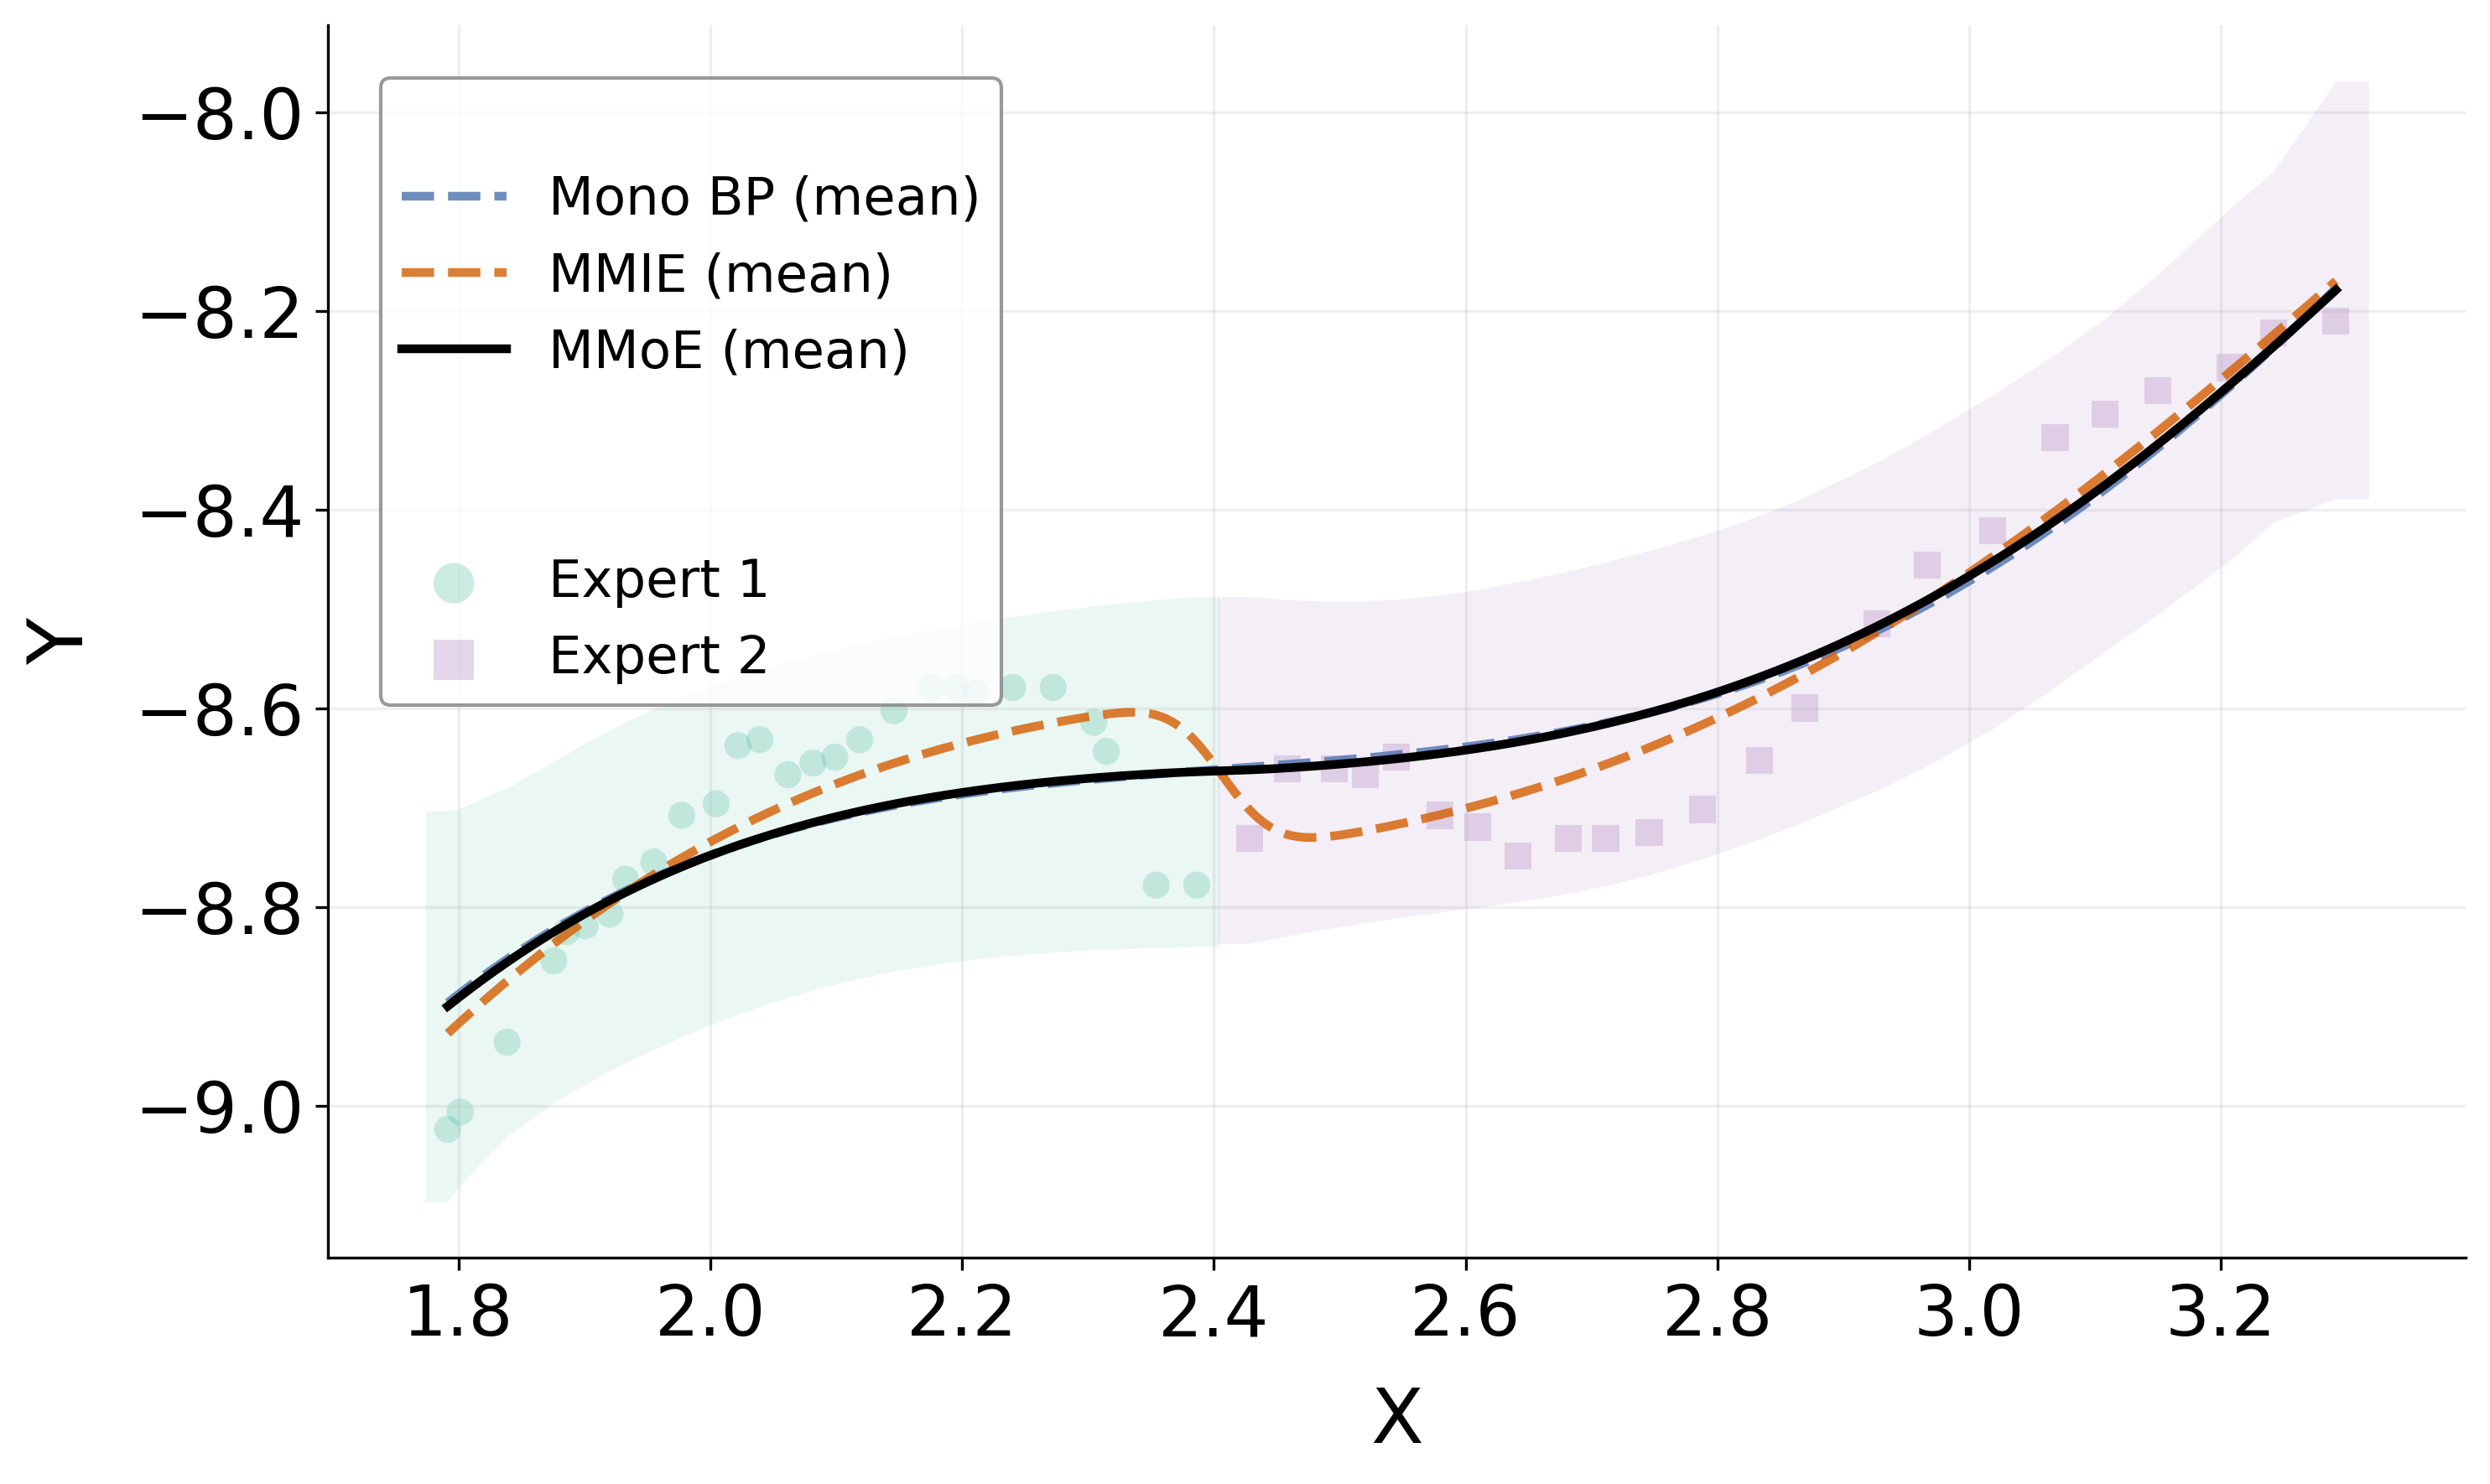

time took: 0.004105091094970703 seconds
time took: 0.0029718875885009766 seconds
time took: 0.0027341842651367188 seconds
time took: 0.002583026885986328 seconds
time took: 0.0027980804443359375 seconds
time took: 0.002774953842163086 seconds
time took: 0.0025148391723632812 seconds
time took: 0.002877950668334961 seconds
time took: 0.002635955810546875 seconds
time took: 0.0028030872344970703 seconds
time took: 0.002569913864135742 seconds
time took: 0.002516031265258789 seconds
time took: 0.0025649070739746094 seconds
time took: 0.0026628971099853516 seconds
time took: 0.002573728561401367 seconds
time took: 0.002485990524291992 seconds
time took: 0.0025899410247802734 seconds
time took: 0.002933025360107422 seconds
time took: 0.002643108367919922 seconds
time took: 0.002552032470703125 seconds
time took: 0.0025463104248046875 seconds
time took: 0.0033740997314453125 seconds
time took: 0.0026388168334960938 seconds
time took: 0.0024857521057128906 seconds
time took: 0.003054141998291

In [21]:
# generate the figure for GP
_, _, _, gpr_model = no_mixture(mixed_X=mixed_X_train, mixed_Y=mixed_Y_train, mixed_X_test=None, mixed_Y_test=None, plot_mixture_pred=True, case_study=case_study, save_file=save_file,
                                import_proposed_MeanPred=True, 
                                import_proposed_CIPred=True,
                                import_proposed_DataPred=True,
                                import_baseline_CIPred=False,
                                import_proposed_mCIPred=True,
                                import_baseline_MeanPred=True)

# generate the metrics for GP

if case_study == "turbine":

    total_num_seeds = len(mixed_X_test_filtered)
    
    mse_list = []
    for test_i in range(0, total_num_seeds):
        metrics_pred = no_mixture(mixed_X=mixed_X_train, mixed_Y=mixed_Y_train, mixed_X_test=mixed_X_test_filtered[test_i], mixed_Y_test=mixed_Y_test_filtered[test_i], show_mono=False, case_study=case_study, gpr_model=gpr_model)
        mse_list.append(metrics_pred[0])

    print('For filtered test set:')
    print(f'average mse over {total_num_seeds} seeds is {sum(mse_list)/total_num_seeds}')
    print(f'SE of mse is {np.std(mse_list)/np.sqrt(total_num_seeds)}')

    # repeat
    mse_list = []
    for test_i in range(0, total_num_seeds):
        metrics_pred = no_mixture(mixed_X=mixed_X_train, mixed_Y=mixed_Y_train, mixed_X_test=mixed_X_test_unfiltered[test_i], mixed_Y_test=mixed_Y_test_unfiltered[test_i], show_mono=False, case_study=case_study, gpr_model=gpr_model)
        mse_list.append(metrics_pred[0])

    print('For unfiltered test set:')
    print(f'average mse over {total_num_seeds} seeds is {sum(mse_list)/total_num_seeds}')
    print(f'SE of mse is {np.std(mse_list)/np.sqrt(total_num_seeds)}')
        
else:
    total_num_seeds = len(mixed_X_test)
    
    mse_list = []
    for test_i in range(0, total_num_seeds):
        metrics_pred = no_mixture(mixed_X=mixed_X_train, mixed_Y=mixed_Y_train, mixed_X_test=mixed_X_test[test_i], mixed_Y_test=mixed_Y_test[test_i], show_mono=False, case_study=case_study, gpr_model=gpr_model)
        mse_list.append(metrics_pred[0])
    
    print(f'average mse over {total_num_seeds} seeds is {sum(mse_list)/total_num_seeds}')
    print(f'SE of mse is {np.std(mse_list)/np.sqrt(total_num_seeds)}')
